# 14 — Feature Engineering for Weak Supervision and Stage 1/2 Training

This notebook converts the joined contract-supplier dataset into an enriched feature table for the thesis pipeline. The feature engineering step is important because the raw joined table combines several data views — contracts, financials, ESG, news, market/stocks, macro indexes, and gold labels — that are not directly comparable in their raw form.

The objective is to transform these raw fields into interpretable and model-ready signals. These signals serve two purposes: first, they provide thresholds and indicators for Snorkel weak labeling functions; second, they become input features for the Stage 1 TabularMLP and the Stage 2 meta-learning adaptation experiments.


In [63]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from master_thesis.config import DATA_PROCESSED

In [64]:
import pandas as pd
import numpy as np

from master_thesis.data_utils import load_processed, save_processed
import seaborn as sns
import matplotlib.pyplot as plt


In [65]:
df_final_no_spend = load_processed(
    "contract_with_gold.csv",
    low_memory=False,
    dtype={
        "terminated": "str",
        "supplier_number": "str",
    },
)

print("Input shape:", df_final_no_spend.shape)
display(df_final_no_spend.head())

Input shape: (9201, 147)


,contract_id,contract_number,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,...,LPI_Score,Customs,Infrastructure,International_Shipments,Logistics_Competence,Tracking_Tracing,Timeliness,PPI_Value,gold_y,gold_department
0,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,3.991859,3.918058,3.95873,3.530159,4.007843,4.176078,4.407843,84.4,NaN,NaN
1,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,3.991859,3.918058,3.95873,3.530159,4.007843,4.176078,4.407843,83.9,NaN,NaN
2,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,3.991859,3.918058,3.95873,3.530159,4.007843,4.176078,4.407843,79.9,NaN,NaN
3,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,3.991859,3.918058,3.95873,3.530159,4.007843,4.176078,4.407843,100.0,NaN,NaN
4,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,3.991859,3.918058,3.95873,3.530159,4.007843,4.176078,4.407843,147.0,NaN,NaN


# Feature engineering design

Each feature block below targets a specific renegotiation signal. The guiding principle is to preserve useful raw information while adding interpretable binary flags and interaction features that reflect mechanisms relevant to contract renegotiation: supplier financial stress, ESG underperformance, external market transparency, country-level logistics risk, news attention, and contract lifecycle pressure.


In [66]:
df_features = df_final_no_spend.copy()

In [67]:
print(df_features.shape)
print(df_features.columns.tolist())

(9201, 147)
['contract_id', 'contract_number', 'contract_name', 'contract_status', 'contract_owner_cost_centre', 'terminated', 'term_type', 'start_date', 'expiration_date', 'supplier_id', 'supplier_number', 'supplier_display_name', 'payment_terms', 'incoterms', 'contract_currency_code', 'contract_value', 'contract_value_dkk', 'contract_type', 'nn_contract_type', 'contract_commodity', 'team', 'unit', 'company_country', 'start_year', 'expiry_year', 'open_ended_contract', 'end_year', 'start_year_capped', 'observation_year', 'years_to_expiry', 'contract_age_years', 'expiry_pressure_bucket', 'department_from_cost_center', 'department', 'moodys_bvd_id', 'fin_moodys_company_name', 'fin_closing_year', 'fin_closing_date', 'fin_created_at_utc', 'fin_Status', 'fin_Implied_rating', 'fin_risk_level', 'fin_Financial_level', 'fin_output_text', 'fin_Implied_rating - original', 'fin_Number_of_months', 'fin_Net_Salesth_DKK', 'fin_Operating_revenue_Turnover_th_DKK', 'fin_Gross_profit_th_DKK', 'fin_EBIT_t

In [68]:
df_contracts_per_department = (
    df_features
    .groupby("department", dropna=False)["contract_id"]
    .nunique()
    .reset_index(name="unique_contract_count")
    .sort_values("unique_contract_count", ascending=False)
)

print(df_contracts_per_department)

                                 department  unique_contract_count
3                         Devices & Needles                    476
4                  Drug Product Outsourcing                    300
5                Drug Substance Outsourcing                    298
9                        Packaging Material                    289
11                   Raw Materials & Energy                    281
10  Quality, Production Services & Supplies                    215
1             Bioprocessing & Raw Materials                    113
8                                 Logistics                     94
2              Bioprocessing and Excipients                     59
0          Alliance, Acquisitions & PPM CoE                     35
14                                      NaN                     22
12                Strategic Sourcing US Hub                      9
6    Global Strategic Outsourcing & Devices                      8
7            HI Warehouse Expansion Program                   

## Financial features

The financial view targets supplier resilience and financial stress. This matters for renegotiation prediction because financially pressured suppliers may be more likely to request price increases, payment-term changes, volume commitments, or other contractual adjustments. The engineering decision is to retain useful raw ratios while adding interpretable stress flags that can be used directly by Snorkel labeling functions.

Based on EDA, `fin_profit_margin` and `fin_ebit_margin` are treated as redundant because they have a high Pearson correlation. EBIT margin is preferred because it reflects operating profitability before interest and tax, making it more comparable across suppliers with different financing and tax structures.


Helper functions

In [69]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """Safely divide two Series and return NaN where denominator is 0 or missing."""
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def make_missing_flag(df: pd.DataFrame, col: str, flag_name: str | None = None) -> pd.DataFrame:
    """Create a missingness flag for a column."""
    if flag_name is None:
        flag_name = f"{col}_missing_flag"
    df[flag_name] = df[col].isna().astype(int)
    return df


Standardize columns

In [70]:
financial_column_map = {
    "fin_Implied_rating": "fin_implied_rating",
    "fin_risk_level": "fin_risk_level",
    "fin_Financial_level": "fin_financial_level",
    "fin_financial_risk_score": "fin_financial_risk_score",
    "fin_Current_ratio": "fin_current_ratio",
    "fin_Gearing": "fin_gearing",
    "fin_Long_term_Gearing": "fin_long_term_gearing",
    "fin_Short_term_Gearing": "fin_short_term_gearing",
    "fin_Debt_Asset_ratio": "fin_debt_asset_ratio",
    "fin_Interest_coverage_ratio": "fin_interest_coverage_ratio",
    "fin_Solvency_ratio_Asset_based": "fin_solvency_ratio_asset_based",
    "fin_Long_term_liabilities_Equity_ratio": "fin_long_term_liabilities_equity_ratio",
    "fin_Short_term_liabilities_Equity_ratio": "fin_short_term_liabilities_equity_ratio",
    "fin_Profit_margin": "fin_profit_margin",
    "fin_EBIT_margin": "fin_ebit_margin",
    "fin_ROE_using_Net_income": "fin_roe_net_income",
    "fin_ROA_using_Net_income": "fin_roa_net_income",
}

for old_col, new_col in financial_column_map.items():
    if old_col in df_features.columns and new_col not in df_features.columns:
        df_features = df_features.rename(columns={old_col: new_col})

Insure numerical values 

In [71]:
numeric_fin_cols = [
    "fin_financial_risk_score",
    "fin_current_ratio",
    "fin_gearing",
    "fin_long_term_gearing",
    "fin_short_term_gearing",
    "fin_debt_asset_ratio",
    "fin_interest_coverage_ratio",
    "fin_solvency_ratio_asset_based",
    "fin_long_term_liabilities_equity_ratio",
    "fin_short_term_liabilities_equity_ratio",
    "fin_profit_margin",
    "fin_ebit_margin",
    "fin_roe_net_income",
    "fin_roa_net_income",
]

for col in numeric_fin_cols:
    if col in df_features.columns:
        df_features[col] = pd.to_numeric(df_features[col], errors="coerce")

Missing flags

In [72]:
missing_flag_cols = [
    "fin_implied_rating",
    "fin_risk_level",
    "fin_financial_level",
    "fin_financial_risk_score",
    "fin_current_ratio",
    "fin_gearing",
    "fin_short_term_gearing",
    "fin_long_term_gearing",
    "fin_interest_coverage_ratio",
    "fin_ebit_margin",
]

for col in missing_flag_cols:
    if col in df_features.columns:
        df_features = make_missing_flag(df_features, col, f"{col}_missing_flag")

### Rating / summarized risk features

The first group of financial features captures **high-level external or summarized risk assessments**. These variables are useful because they compress complex financial information into interpretable risk categories that can be translated into weak labeling rules.

In this project, the most important variables in this category are:

- `fin_implied_rating`
- `fin_risk_level`
- `fin_financial_level`
- `fin_financial_risk_score`

In [73]:
if "fin_implied_rating" in df_features.columns:
    rating_order = {
        "Aaa": 1,
        "Aa": 2,
        "A": 3,
        "Baa": 4,
        "Ba": 5,
        "B": 6,
        "Caa": 7,
        "Ca": 8,
        "C": 9,
    }
    df_features["fin_implied_rating_ordinal"] = df_features["fin_implied_rating"].map(rating_order)

    df_features["fin_flag_weak_implied_rating"] = (
        df_features["fin_implied_rating"].isin(["Ba", "B", "Caa", "Ca", "C"])
    ).astype(int)

    df_features["fin_flag_moderate_or_worse_rating"] = (
        df_features["fin_implied_rating"].isin(["Baa", "Ba", "B", "Caa", "Ca", "C"])
    ).astype(int)

if "fin_risk_level" in df_features.columns:
    df_features["fin_flag_risk_take_caution_or_worse"] = (
        df_features["fin_risk_level"].isin(["Take caution", "Do not source"])
    ).astype(int)

    df_features["fin_flag_risk_do_not_source"] = (
        df_features["fin_risk_level"].eq("Do not source")
    ).astype(int)

if "fin_financial_level" in df_features.columns:
    df_features["fin_flag_high_financial_risk_level"] = (
        df_features["fin_financial_level"].isin(["High financial risk", "Very high financial risk"])
    ).astype(int)

if "fin_financial_risk_score" in df_features.columns:
    df_features["fin_flag_financial_risk_score_high"] = (
        df_features["fin_financial_risk_score"] >= 3
    ).astype(int)

    df_features["fin_flag_financial_risk_score_very_high"] = (
        df_features["fin_financial_risk_score"] >= 4
    ).astype(int)

### Liquidity stress features

Liquidity stress reflects whether a supplier can meet its short-term obligations. A standard and widely used liquidity measure is the **current ratio**, defined as:


$\text{Current Ratio} = \frac{\text{Current Assets}}{\text{Current Liabilities}}$




The current ratio measures a firm's ability to cover short-term obligations with short-term assets. Lower values indicate weaker liquidity and potentially higher short-term financial pressure.  [oai_citation:1‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/accounting/current-ratio-formula/?utm_source=chatgpt.com)

In the feature engineering step, the raw current ratio is kept, but it is also converted into interpretable stress flags such as:

- `fin_flag_liquidity_stress`
- `fin_flag_severe_liquidity_stress`
- `fin_flag_strong_liquidity`

In [74]:
if "fin_current_ratio" in df_features.columns:
    df_features["fin_flag_liquidity_stress"] = (
        df_features["fin_current_ratio"] < 1
    ).astype(int)

    df_features["fin_flag_severe_liquidity_stress"] = (
        df_features["fin_current_ratio"] < 0.75
    ).astype(int)

    df_features["fin_flag_strong_liquidity"] = (
        df_features["fin_current_ratio"] >= 2
    ).astype(int)

### Leverage / liability stress features

Leverage features aim to capture whether a supplier is under pressure from debt and liabilities relative to equity or assets. This is relevant because highly leveraged firms may be more exposed to refinancing pressure, reduced flexibility, or short-term commercial sensitivity.

A common leverage ratio is the debt-to-equity ratio (also described as gearing), typically expressed as:


$\text{Debt-to-Equity Ratio} = \frac{\text{Total Debt}}{\text{Shareholders' Equity}}$


A related solvency-oriented ratio is the debt-to-asset ratio:


$\text{Debt-to-Asset Ratio} = \frac{\text{Total Debt}}{\text{Total Assets}}$


These ratios are standard measures of leverage and financial burden. Higher values indicate greater reliance on debt financing and potentially greater financial pressure.  [oai_citation:2‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/commercial-lending/debt-to-equity-ratio-formula/?utm_source=chatgpt.com)

In this project, leverage is represented through features such as:

- `fin_gearing`
- `fin_long_term_gearing`
- `fin_short_term_gearing`
- `fin_debt_asset_ratio`
- `fin_long_term_liabilities_equity_ratio`
- `fin_short_term_liabilities_equity_ratio`

These are engineered into stress indicators such as:

- high gearing
- high short-term gearing
- high debt-to-asset burden
- high liabilities-to-equity burden

In [75]:
if "fin_gearing" in df_features.columns:
    df_features["fin_flag_gearing_high"] = (
        df_features["fin_gearing"] > 100
    ).astype(int)

if "fin_long_term_gearing" in df_features.columns:
    df_features["fin_flag_long_term_gearing_high"] = (
        df_features["fin_long_term_gearing"] > 100
    ).astype(int)

if "fin_short_term_gearing" in df_features.columns:
    df_features["fin_flag_short_term_gearing_high"] = (
        df_features["fin_short_term_gearing"] > 100
    ).astype(int)

if "fin_debt_asset_ratio" in df_features.columns:
    df_features["fin_flag_debt_asset_high"] = (
        df_features["fin_debt_asset_ratio"] > 0.70
    ).astype(int)

    df_features["fin_flag_debt_asset_very_high"] = (
        df_features["fin_debt_asset_ratio"] > 0.85
    ).astype(int)

if "fin_long_term_liabilities_equity_ratio" in df_features.columns:
    df_features["fin_flag_long_term_liab_equity_high"] = (
        df_features["fin_long_term_liabilities_equity_ratio"] > 100
    ).astype(int)

if "fin_short_term_liabilities_equity_ratio" in df_features.columns:
    df_features["fin_flag_short_term_liab_equity_high"] = (
        df_features["fin_short_term_liabilities_equity_ratio"] > 100
    ).astype(int)

### Coverage / solvency features

Another important financial dimension is whether a supplier generates enough operating earnings to service debt, and whether its balance sheet shows adequate solvency.

The **interest coverage ratio** is commonly defined as:


$\text{Interest Coverage Ratio} = \frac{\text{EBIT}}{\text{Interest Expense}}$


This ratio measures how well operating earnings can cover interest payments. Low values indicate weaker debt-servicing capacity and are often interpreted as a sign of financial stress.  [oai_citation:3‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/commercial-lending/interest-coverage-ratio/?utm_source=chatgpt.com)

Solvency measures are broader indicators of longer-term financial resilience. Solvency ratios are commonly used to assess whether a company has enough assets and equity support to sustain its financial obligations over time.  [oai_citation:4‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/commercial-lending/solvency-ratio/?utm_source=chatgpt.com)

In this project, this group includes variables such as:

- `fin_interest_coverage_ratio`
- `fin_solvency_ratio_asset_based`

These are transformed into interpretable flags such as:

- `fin_flag_interest_coverage_stress`
- `fin_flag_interest_coverage_weak`
- `fin_flag_low_solvency`
- `fin_flag_very_low_solvency`

In [76]:
if "fin_interest_coverage_ratio" in df_features.columns:
    df_features["fin_flag_interest_coverage_stress"] = (
        df_features["fin_interest_coverage_ratio"] < 1
    ).astype(int)

    df_features["fin_flag_interest_coverage_weak"] = (
        df_features["fin_interest_coverage_ratio"] < 2
    ).astype(int)

if "fin_solvency_ratio_asset_based" in df_features.columns:
    df_features["fin_flag_low_solvency"] = (
        df_features["fin_solvency_ratio_asset_based"] < 20
    ).astype(int)

    df_features["fin_flag_very_low_solvency"] = (
        df_features["fin_solvency_ratio_asset_based"] < 10
    ).astype(int)

### Profitability stress features

Profitability stress captures whether a supplier generates positive operating earnings. The EDA showed that `fin_profit_margin` and `fin_ebit_margin` are highly correlated, so keeping both raw variables and both binary flags would give the model the same signal multiple times. This notebook therefore keeps EBIT margin and the negative EBIT margin flag, while removing profit margin and its negative-profit flag before saving.

The threshold for `fin_flag_negative_ebit_margin` is domain-based: EBIT margin below zero means the supplier is not profitable at the operating level.


In [77]:
if "fin_ebit_margin" in df_features.columns:
    # Domain threshold: EBIT margin below 0 indicates negative operating profitability.
    # EDA decision: prefer EBIT margin over profit margin because profit margin is highly correlated and affected by interest/tax structure.
    df_features["fin_flag_negative_ebit_margin"] = (
        df_features["fin_ebit_margin"] < 0
    ).astype(int)

    df_features["fin_flag_profitability_stress"] = df_features["fin_flag_negative_ebit_margin"]

# Redundancy consolidation: remove the duplicate negative-profit flag if it already exists from earlier runs.
df_features = df_features.drop(columns=["fin_flag_negative_profit_margin"], errors="ignore")


### Return stress features

Return-based measures describe how effectively a company turns assets or equity into profit.

Two standard ratios are:


$\text{ROA} = \frac{\text{Net Income}}{\text{Total Assets}}$



$\text{ROE} = \frac{\text{Net Income}}{\text{Shareholders' Equity}}$

ROA measures how effectively assets generate profit, while ROE measures returns delivered to shareholders. Both are standard indicators of financial performance and efficiency.  [oai_citation:6‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/accounting/return-on-assets-roa-formula/?utm_source=chatgpt.com)

In this project, these are represented by:

- `fin_roa_net_income`
- `fin_roe_net_income`

These variables are mainly used as supporting stress indicators rather than the core financial labeling rules. They are converted into simple binary features such as:

- `fin_flag_negative_roa`
- `fin_flag_negative_roe`

In [78]:
if "fin_roe_net_income" in df_features.columns:
    df_features["fin_flag_negative_roe"] = (
        df_features["fin_roe_net_income"] < 0
    ).astype(int)

if "fin_roa_net_income" in df_features.columns:
    df_features["fin_flag_negative_roa"] = (
        df_features["fin_roa_net_income"] < 0
    ).astype(int)

### Composite financial stress features

In addition to individual financial indicators, the feature engineering step also creates composite stress measures that summarize the number of simultaneous warning signs observed for a supplier.

The idea is that financial risk is often not expressed through one variable alone, but through a combination of signals such as:

- weak rating
- low liquidity
- high leverage
- weak interest coverage
- low solvency
- negative profitability

To capture this, individual binary stress flags are summed into a total stress count:


$\text{Total Financial Stress Flags} = \sum_{j=1}^{J} \text{StressFlag}_j$


This produces a simple composite score that can then be thresholded into features such as:

- `fin_total_stress_flags`
- `fin_flag_multiple_financial_stress_signals`
- `fin_flag_severe_financial_stress`

In [79]:
stress_flag_cols = [
    "fin_flag_weak_implied_rating",
    "fin_flag_risk_take_caution_or_worse",
    "fin_flag_high_financial_risk_level",
    "fin_flag_financial_risk_score_high",
    "fin_flag_liquidity_stress",
    "fin_flag_short_term_gearing_high",
    "fin_flag_debt_asset_high",
    "fin_flag_interest_coverage_stress",
    "fin_flag_low_solvency",
    "fin_flag_profitability_stress",
    "fin_flag_negative_roe",
    "fin_flag_negative_roa",
]

existing_stress_flag_cols = [c for c in stress_flag_cols if c in df_features.columns]

if existing_stress_flag_cols:
    df_features["fin_total_stress_flags"] = df_features[existing_stress_flag_cols].sum(axis=1)

    df_features["fin_flag_multiple_financial_stress_signals"] = (
        df_features["fin_total_stress_flags"] >= 2
    ).astype(int)

    df_features["fin_flag_severe_financial_stress"] = (
        df_features["fin_total_stress_flags"] >= 3
    ).astype(int)

In [80]:
created_financial_features = [
    c for c in df_features.columns
    if c.startswith("fin_flag_")
    or c.endswith("_missing_flag")
    or c == "fin_implied_rating_ordinal"
    or c == "fin_total_stress_flags"
]

print(f"Number of created financial features: {len(created_financial_features)}")
print(created_financial_features)

display(df_features[created_financial_features].head())

Number of created financial features: 39
['fin_implied_rating_missing_flag', 'fin_risk_level_missing_flag', 'fin_financial_level_missing_flag', 'fin_financial_risk_score_missing_flag', 'fin_current_ratio_missing_flag', 'fin_gearing_missing_flag', 'fin_short_term_gearing_missing_flag', 'fin_long_term_gearing_missing_flag', 'fin_interest_coverage_ratio_missing_flag', 'fin_ebit_margin_missing_flag', 'fin_implied_rating_ordinal', 'fin_flag_weak_implied_rating', 'fin_flag_moderate_or_worse_rating', 'fin_flag_risk_take_caution_or_worse', 'fin_flag_risk_do_not_source', 'fin_flag_high_financial_risk_level', 'fin_flag_financial_risk_score_high', 'fin_flag_financial_risk_score_very_high', 'fin_flag_liquidity_stress', 'fin_flag_severe_liquidity_stress', 'fin_flag_strong_liquidity', 'fin_flag_gearing_high', 'fin_flag_long_term_gearing_high', 'fin_flag_short_term_gearing_high', 'fin_flag_debt_asset_high', 'fin_flag_debt_asset_very_high', 'fin_flag_long_term_liab_equity_high', 'fin_flag_short_term_l

,fin_implied_rating_missing_flag,fin_risk_level_missing_flag,fin_financial_level_missing_flag,fin_financial_risk_score_missing_flag,fin_current_ratio_missing_flag,fin_gearing_missing_flag,fin_short_term_gearing_missing_flag,fin_long_term_gearing_missing_flag,fin_interest_coverage_ratio_missing_flag,fin_ebit_margin_missing_flag,...,fin_flag_interest_coverage_weak,fin_flag_low_solvency,fin_flag_very_low_solvency,fin_flag_negative_ebit_margin,fin_flag_profitability_stress,fin_flag_negative_roe,fin_flag_negative_roa,fin_total_stress_flags,fin_flag_multiple_financial_stress_signals,fin_flag_severe_financial_stress
0,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [81]:
print(df_final_no_spend.shape)
print(df_features.shape)

(9201, 147)
(9201, 186)


The financial view contains many raw accounting ratios and balance-sheet measures. For modeling, many of these raw variables can be retained. However, for weak supervision, simple and interpretable threshold-based indicators are more useful than raw continuous values.

Therefore, the financial feature engineering step transforms the raw financial variables into a smaller set of semantically meaningful stress indicators, covering:

- external/summarized risk
- liquidity stress
- leverage and liability stress
- debt-servicing stress
- solvency stress
- profitability stress
- return-based performance stress

## News Features

## ESG features

### ESG peer-relative underperformance flag

This section targets supplier sustainability risk relative to industry peers. ESG performance matters for renegotiation prediction because weak ESG performance can increase compliance, reputational, and supplier-review pressure. The engineering decision is to add `esg_below_industry_min`, a conservative binary flag indicating that the supplier's ESG score falls below the minimum value observed for its industry sector.

This threshold is intentionally conservative: a supplier below the sector minimum is positioned at the tail of ESG performance within its own peer group, making the signal easier to interpret in both Snorkel rules and thesis discussion.


In [82]:
# Standardize common ESG column variants if present.
esg_column_map = {
    "industry_min": "esg_industry_min",
    "industry_max": "esg_industry_max",
    "esg_overall": "esg_esg_overall",
    "esg_industry_adjusted": "esg_esg_industry_adjusted",
}

for old_col, new_col in esg_column_map.items():
    if old_col in df_features.columns and new_col not in df_features.columns:
        df_features = df_features.rename(columns={old_col: new_col})

esg_numeric_cols = [c for c in df_features.columns if c.startswith("esg_")]
for col in esg_numeric_cols:
    df_features[col] = pd.to_numeric(df_features[col], errors="coerce")

esg_score_candidates = ["esg_esg_overall", "esg_overall", "esg_score", "esg_esg_industry_adjusted"]
esg_min_candidates = ["esg_industry_min", "industry_min"]

esg_score_col = next((c for c in esg_score_candidates if c in df_features.columns), None)
esg_min_col = next((c for c in esg_min_candidates if c in df_features.columns), None)

if esg_score_col is not None and esg_min_col is not None:
    # EDA threshold: industry_min is available and clean; below it means below the peer-group floor.
    df_features["esg_below_industry_min"] = (
        df_features[esg_score_col] < df_features[esg_min_col]
    ).astype(int)
    display(df_features[[esg_score_col, esg_min_col, "esg_below_industry_min"]].head())
else:
    print("Could not create esg_below_industry_min because ESG score or industry minimum column is missing.")


,esg_esg_overall,esg_industry_min,esg_below_industry_min
0,NaN,NaN,0
1,NaN,NaN,0
2,NaN,NaN,0
3,NaN,NaN,0
4,NaN,NaN,0


## Stock and market features

The market/stocks view targets public market stress and supplier transparency. The EDA showed that market data is missing for most records because most suppliers are privately held. This means missing stock data should not be interpreted as “no market stress.” The engineering decision is to add `supplier_is_publicly_listed`, a structural availability flag indicating whether any stock-market signal exists for the supplier.


In [83]:
df_features = df_features.copy()

In [84]:
market_numeric_cols = [
    "vol_shock_ratio",
    "vol_trend_slope",
    "market_cap_volatility",
    "Price_trends_52 weeks_%",
    "market_beta_1y",
    "Earnings_per_share_DKK",
    "price_trend_slope"
]

for col in market_numeric_cols:
    if col in df_features.columns:
        df_features[col] = pd.to_numeric(df_features[col], errors="coerce")

Structural availability feature

In [85]:
stock_view_source_cols = [
    c for c in [
        "vol_shock_ratio",
        "market_cap_volatility",
        "Price_trends_52 weeks_%",
        "market_beta_1y",
        "Earnings_per_share_DKK",
        "price_trend_slope"
    ] if c in df_features.columns
]

if len(stock_view_source_cols) > 0:
    df_features["market_has_stock_view"] = (
        df_features[stock_view_source_cols].notna().any(axis=1)
    ).astype(int)

### Public listing / market transparency flag

This feature targets external data transparency. A supplier with observable market data is likely publicly listed or otherwise externally covered, while a supplier with no market data is typically privately held. The flag does not claim that private suppliers are riskier by default; rather, it distinguishes structural data absence from genuine absence of market stress signals. This matters because Stage 1 and Stage 2 models otherwise cannot distinguish “no market stress observed” from “no market data available.”


In [86]:
# EDA finding: stock data is missing for approximately 96.5% of records.
# Threshold/source: supplier_is_publicly_listed = 1 if any stock/market source column is non-null.
stock_listing_source_cols = [
    c for c in [
        "avg_vol",
        "std_vol",
        "max_vol",
        "min_vol",
        "avg_closing_price",
        "price_volatility_score",
        "vol_shock_ratio",
        "market_cap_volatility",
        "Price_trends_52 weeks_%",
        "market_beta_1y",
        "Earnings_per_share_DKK",
        "price_trend_slope",
    ]
    if c in df_features.columns
]

if stock_listing_source_cols:
    df_features["supplier_is_publicly_listed"] = (
        df_features[stock_listing_source_cols].notna().any(axis=1)
    ).astype(int)

    # Backward-compatible alias used by earlier market feature logic.
    df_features["market_has_stock_view"] = df_features["supplier_is_publicly_listed"]

    print("Publicly listed/share of records with market data:")
    print(df_features["supplier_is_publicly_listed"].value_counts(normalize=True, dropna=False).rename("share"))
else:
    print("No stock source columns found; supplier_is_publicly_listed was not created.")


Publicly listed/share of records with market data:
supplier_is_publicly_listed
0    0.977502
1    0.022498
Name: share, dtype: float64


High volume shock Based on  EDA:  90% ~ 10.2, 95% ~ 19.5

In [87]:
if "vol_shock_ratio" in df_features.columns:
    df_features["market_flag_high_volume_shock"] = (
        df_features["vol_shock_ratio"] >= 10
    ).astype(int)


 High market cap volatility Based on EDA:  90% ~ 0.236, 95% ~ 0.299

In [88]:
if "market_cap_volatility" in df_features.columns:
    df_features["market_flag_high_market_cap_volatility"] = (
        df_features["market_cap_volatility"] >= 0.24
    ).astype(int)

Negative volume trend

In [89]:
if "vol_trend_slope" in df_features.columns:
    df_features["market_flag_negative_volume_trend"] = (
        df_features["vol_trend_slope"] < 0
    ).astype(int)

Negative price trend

In [90]:
if "price_trend_slope" in df_features.columns:
    df_features["market_flag_negative_price_trend"] = (
        df_features["price_trend_slope"] < 0
    ).astype(int)

Negative 52-week price trend

In [91]:
if "Price_trends_52 weeks_%" in df_features.columns:
    df_features["market_flag_negative_52w_price_trend"] = (
        df_features["Price_trends_52 weeks_%"] < 0
    ).astype(int)

High beta looked discrete in the EDA, often 0 / 1 / 2

In [92]:
if "market_beta_1y" in df_features.columns:
    df_features["market_flag_high_beta"] = (
        df_features["market_beta_1y"] >= 2
    ).astype(int)

 Negative EPS

In [93]:
if "Earnings_per_share_DKK" in df_features.columns:
    df_features["market_flag_negative_eps"] = (
        df_features["Earnings_per_share_DKK"] < 0
    ).astype(int)

Risk level from stock-price-based risk label

In [94]:
if "Risk level_stock_closing_price" in df_features.columns:
    df_features["market_flag_stock_price_take_caution_or_worse"] = (
        df_features["Risk level_stock_closing_price"].isin(["Take caution", "Do not source"])
    ).astype(int)

Log-transformed shock ratio since raw vol_shock_ratio is extremely skewed

In [95]:
if "vol_shock_ratio" in df_features.columns:
    df_features["market_log_vol_shock_ratio"] = np.log1p(df_features["vol_shock_ratio"])

Final kept market features

In [96]:
market_features_keep = [
    "market_has_stock_view",
    "market_flag_high_volume_shock",
    "market_flag_high_market_cap_volatility",
    "market_flag_negative_volume_trend",
    "market_flag_negative_price_trend",
    "market_flag_negative_52w_price_trend",
    "market_flag_high_beta",
    "market_flag_negative_eps",
    "market_flag_stock_price_take_caution_or_worse",
    "market_log_vol_shock_ratio",
    "market_total_stress_flags"
]

market_features_keep = [c for c in market_features_keep if c in df_features.columns]

print(market_features_keep)

display(df_features[market_features_keep].head())

['market_has_stock_view', 'market_flag_high_volume_shock', 'market_flag_high_market_cap_volatility', 'market_flag_negative_volume_trend', 'market_flag_negative_price_trend', 'market_flag_negative_52w_price_trend', 'market_flag_high_beta', 'market_flag_negative_eps', 'market_flag_stock_price_take_caution_or_worse', 'market_log_vol_shock_ratio']


,market_has_stock_view,market_flag_high_volume_shock,market_flag_high_market_cap_volatility,market_flag_negative_volume_trend,market_flag_negative_price_trend,market_flag_negative_52w_price_trend,market_flag_high_beta,market_flag_negative_eps,market_flag_stock_price_take_caution_or_worse,market_log_vol_shock_ratio
0,0,0,0,0,0,0,0,0,0,NaN
1,0,0,0,0,0,0,0,0,0,NaN
2,0,0,0,0,0,0,0,0,0,NaN
3,0,0,0,0,0,0,0,0,0,NaN
4,0,0,0,0,0,0,0,0,0,NaN


## Macro index feature: dataset-relative logistics risk

This section targets country-level logistics conditions using the Logistics Performance Index (LPI). A fixed global threshold around 3.0–3.2 is not well calibrated for this dataset because Novo Nordisk's supplier countries are concentrated in Europe and developed Asia, where LPI scores are typically higher. The engineering decision is therefore to compute the median LPI score among supplier countries present in the dataset and flag contracts below that observed median.

This makes `lpi_relative_risk` a dataset-relative signal: it identifies suppliers operating in weaker logistics environments relative to the company's actual supplier-country distribution, rather than relative to a global country distribution.


In [97]:
lpi_col = next((c for c in ["LPI_Score", "lpi_score", "LPI score"] if c in df_features.columns), None)

if lpi_col is not None:
    df_features[lpi_col] = pd.to_numeric(df_features[lpi_col], errors="coerce")
    supplier_country_lpi_median = df_features[lpi_col].dropna().median()

    # EDA-driven threshold: below the median LPI of supplier countries in this dataset.
    df_features["lpi_relative_risk"] = (
        df_features[lpi_col] < supplier_country_lpi_median
    ).astype(int)

    print(f"Dataset-specific median {lpi_col}: {supplier_country_lpi_median:.3f}")
    display(df_features[[lpi_col, "lpi_relative_risk"]].head())
else:
    print("LPI score column not found; lpi_relative_risk was not created.")


Dataset-specific median LPI_Score: 4.100


,LPI_Score,lpi_relative_risk
0,3.991859,1
1,3.991859,1
2,3.991859,1
3,3.991859,1
4,3.991859,1


## Contract lifecycle interaction feature

This section targets renegotiation pressure from the contract lifecycle. Contract age and time to expiry are useful separately, but their interaction is more informative: a contract that is both old and near expiry combines relationship maturity with renewal pressure. The engineering decision is to create `is_old_and_near_expiry`, equal to 1 when `contract_age_years >= 5` and `years_to_expiry <= 1`.

The threshold is domain-driven: five years indicates a mature relationship, while one year or less to expiry indicates near-term renewal or renegotiation pressure.


In [98]:
# Create the lifecycle interaction only if the two source features exist.
for col in ["contract_age_years", "years_to_expiry", "days_until_expiry", "open_ended_contract"]:
    if col in df_features.columns:
        df_features[col] = pd.to_numeric(df_features[col], errors="coerce")

if {"contract_age_years", "years_to_expiry"}.issubset(df_features.columns):
    # Domain threshold: mature relationship (>=5 years) and near expiry (<=1 year).
    df_features["is_old_and_near_expiry"] = (
        (df_features["contract_age_years"] >= 5)
        & (df_features["years_to_expiry"] <= 1)
    ).astype(int)

    display(df_features[["contract_age_years", "years_to_expiry", "is_old_and_near_expiry"]].head())
else:
    print("contract_age_years and/or years_to_expiry missing; is_old_and_near_expiry was not created.")


,contract_age_years,years_to_expiry,is_old_and_near_expiry
0,0,9,0
1,1,8,0
2,2,7,0
3,3,6,0
4,4,5,0


# Missingness audit and view-level coverage

Multi-view supplier data is naturally incomplete. Missingness is not only a technical issue; it can also reflect supplier transparency, external coverage, or data availability. This section summarizes missingness by view before saving the final feature table, which helps interpret both Snorkel labeling coverage and model behavior.


In [99]:
df_audit = pd.DataFrame({
    "feature": df_features.columns,
    "dtype": df_features.dtypes.astype(str).values,
    "missing_pct": df_features.isna().mean().values * 100,
    "n_unique": df_features.nunique(dropna=True).values
})

def assign_view(col):
    if col.startswith("fin_"):
        return "financial"
    elif col.startswith("esg_"):
        return "esg"
    elif col.startswith("news_"):
        return "news"
    elif col in ["LPI_Score", "Customs", "Infrastructure", "International_Shipments",
                 "Logistics_Competence", "Tracking_Tracing", "Timeliness", "PPI_Value"]:
        return "macro_logistics"
    elif col in ["avg_vol", "std_vol", "max_vol", "min_vol", "vol_stability_score",
                 "vol_shock_ratio", "vol_trend_slope", "avg_market_cap",
                 "market_cap_volatility", "Price_trends_52 weeks_%", "market_beta_1y",
                 "Earnings_per_share_DKK", "Book_value_per_share_DKK", "avg_closing_price",
                 "price_volatility_score", "price_trend_slope"]:
        return "market"
    else:
        return "contract_core"

df_audit["view"] = df_audit["feature"].apply(assign_view)

display(
    df_audit.sort_values(["view", "missing_pct", "feature"])
)

,feature,dtype,missing_pct,n_unique,view
22,company_country,str,0.000000,15,contract_core
134,company_country_clean,str,0.000000,15,contract_core
30,contract_age_years,int64,0.000000,25,contract_core
19,contract_commodity,str,0.000000,139,contract_core
14,contract_currency_code,str,0.000000,16,contract_core
...,...,...,...,...,...
107,news_max_relevance_score,float64,87.120965,11,news
102,news_negative_count,float64,87.120965,8,news
108,news_negative_ratio,float64,87.120965,26,news
104,news_neutral_count,float64,87.120965,10,news


In [100]:
view_groups = {
    "financial": [c for c in df_features.columns if c.startswith("fin_") and not c.endswith("_flag") and not c.endswith("_missing_flag")],
    "esg": [c for c in df_features.columns if c.startswith("esg_")],
    "news": [c for c in df_features.columns if c.startswith("news_")],
}

for view_name, cols in view_groups.items():
    df_features[f"{view_name}_row_missing_pct"] = df_features[cols].isna().mean(axis=1) * 100

display(
    df_features[
        ["contract_id", "observation_year", "financial_row_missing_pct", "esg_row_missing_pct", "news_row_missing_pct"]
    ].head()
)

,contract_id,observation_year,financial_row_missing_pct,esg_row_missing_pct,news_row_missing_pct
0,9675,2018,65.432099,93.333333,100.0
1,9675,2019,65.432099,93.333333,100.0
2,9675,2020,65.432099,93.333333,100.0
3,9675,2021,65.432099,93.333333,100.0
4,9675,2022,65.432099,93.333333,100.0


In [101]:
summary_by_view = (
    df_audit.groupby("view")
    .agg(
        n_features=("feature", "count"),
        avg_missing_pct=("missing_pct", "mean"),
        median_missing_pct=("missing_pct", "median"),
        high_missing_features=("missing_pct", lambda x: (x > 40).sum())
    )
    .reset_index()
)

display(summary_by_view)
display(
    df_audit.sort_values("missing_pct", ascending=False).head(50)
)

,view,n_features,avg_missing_pct,median_missing_pct,high_missing_features
0,contract_core,61,16.929022,0.000000,14
1,esg,15,85.267543,89.001196,14
2,financial,91,47.037410,76.089555,53
3,macro_logistics,8,0.767580,0.728182,0
4,market,16,98.322193,98.489295,16
5,news,9,87.120965,87.120965,9


,feature,dtype,missing_pct,n_unique,view
88,esg_risk_level,float64,100.000000,0,esg
87,esg_company_name,float64,100.000000,0,esg
89,esg_sector,float64,100.000000,0,esg
146,gold_department,str,99.087056,4,contract_core
145,gold_y,float64,99.087056,2,contract_core
113,std_vol,float64,98.489295,48,market
121,market_cap_volatility,float64,98.489295,48,market
112,avg_vol,float64,98.489295,48,market
114,max_vol,float64,98.489295,48,market
115,min_vol,float64,98.489295,48,market


In [102]:
df_features.columns.to_list()

['contract_id',
 'contract_number',
 'contract_name',
 'contract_status',
 'contract_owner_cost_centre',
 'terminated',
 'term_type',
 'start_date',
 'expiration_date',
 'supplier_id',
 'supplier_number',
 'supplier_display_name',
 'payment_terms',
 'incoterms',
 'contract_currency_code',
 'contract_value',
 'contract_value_dkk',
 'contract_type',
 'nn_contract_type',
 'contract_commodity',
 'team',
 'unit',
 'company_country',
 'start_year',
 'expiry_year',
 'open_ended_contract',
 'end_year',
 'start_year_capped',
 'observation_year',
 'years_to_expiry',
 'contract_age_years',
 'expiry_pressure_bucket',
 'department_from_cost_center',
 'department',
 'moodys_bvd_id',
 'fin_moodys_company_name',
 'fin_closing_year',
 'fin_closing_date',
 'fin_created_at_utc',
 'fin_Status',
 'fin_implied_rating',
 'fin_risk_level',
 'fin_financial_level',
 'fin_output_text',
 'fin_Implied_rating - original',
 'fin_Number_of_months',
 'fin_Net_Salesth_DKK',
 'fin_Operating_revenue_Turnover_th_DKK',
 'f

# Correlation analysis before saving

Correlation analysis is used as a final diagnostic before saving the feature table. High correlations do not automatically require removal, but they identify where the model may receive the same signal multiple times. This is especially important before weak labeling because redundant features can lead to redundant labeling functions and artificially inflated confidence in the weak labels.


In [103]:
def numeric_cols_with_prefix(df: pd.DataFrame, prefix: str) -> list[str]:
    return [c for c in df.columns if c.startswith(prefix) and pd.api.types.is_numeric_dtype(df[c])]


def high_corr_pairs(df: pd.DataFrame, cols: list[str], threshold: float = 0.80) -> pd.DataFrame:
    cols = [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    if len(cols) < 2:
        return pd.DataFrame(columns=["feature_1", "feature_2", "corr", "abs_corr"])
    corr = df[cols].corr(method="pearson")
    mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
    out = (
        corr.where(mask)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"})
    )
    out["abs_corr"] = out["corr"].abs()
    return out[out["abs_corr"] >= threshold].sort_values("abs_corr", ascending=False).reset_index(drop=True)


def plot_corr_heatmap(df: pd.DataFrame, cols: list[str], title: str, figsize=(12, 9)):
    cols = [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    if len(cols) < 2:
        print(f"Not enough numeric columns for heatmap: {title}")
        return None, None
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(df[cols].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    return fig, ax


## Financial features correlation heatmap

This block examines numeric financial features. Pairs with absolute correlation above 0.80 should be reviewed for possible consolidation, especially when both variables are also used in Snorkel labeling rules.


,feature_1,feature_2,corr,abs_corr
0,fin_flag_negative_ebit_margin,fin_flag_profitability_stress,1.000000,1.000000
1,fin_flag_high_financial_risk_level,fin_flag_financial_risk_score_high,1.000000,1.000000
2,fin_financial_level_missing_flag,fin_financial_risk_score_missing_flag,1.000000,1.000000
3,fin_implied_rating_missing_flag,fin_risk_level_missing_flag,1.000000,1.000000
4,fin_Total_assets_th_DKK,fin_Total_shareholders'_funds_and_liabilitiest...,1.000000,1.000000
5,fin_Net_Salesth_DKK,fin_Operating_revenue_Turnover_th_DKK,0.999988,0.999988
6,fin_Long_term_debtth_DKK,fin_Non_current_liabilities_th_DKK,0.999512,0.999512
7,fin_Total_assets_th_DKK,fin_Non-current_assetsth_DKK,0.999199,0.999199
8,fin_Non-current_assetsth_DKK,fin_Total_shareholders'_funds_and_liabilitiest...,0.999199,0.999199
9,fin_Interest_paid_th_DKK,fin_Long_term_debtth_DKK,0.999151,0.999151


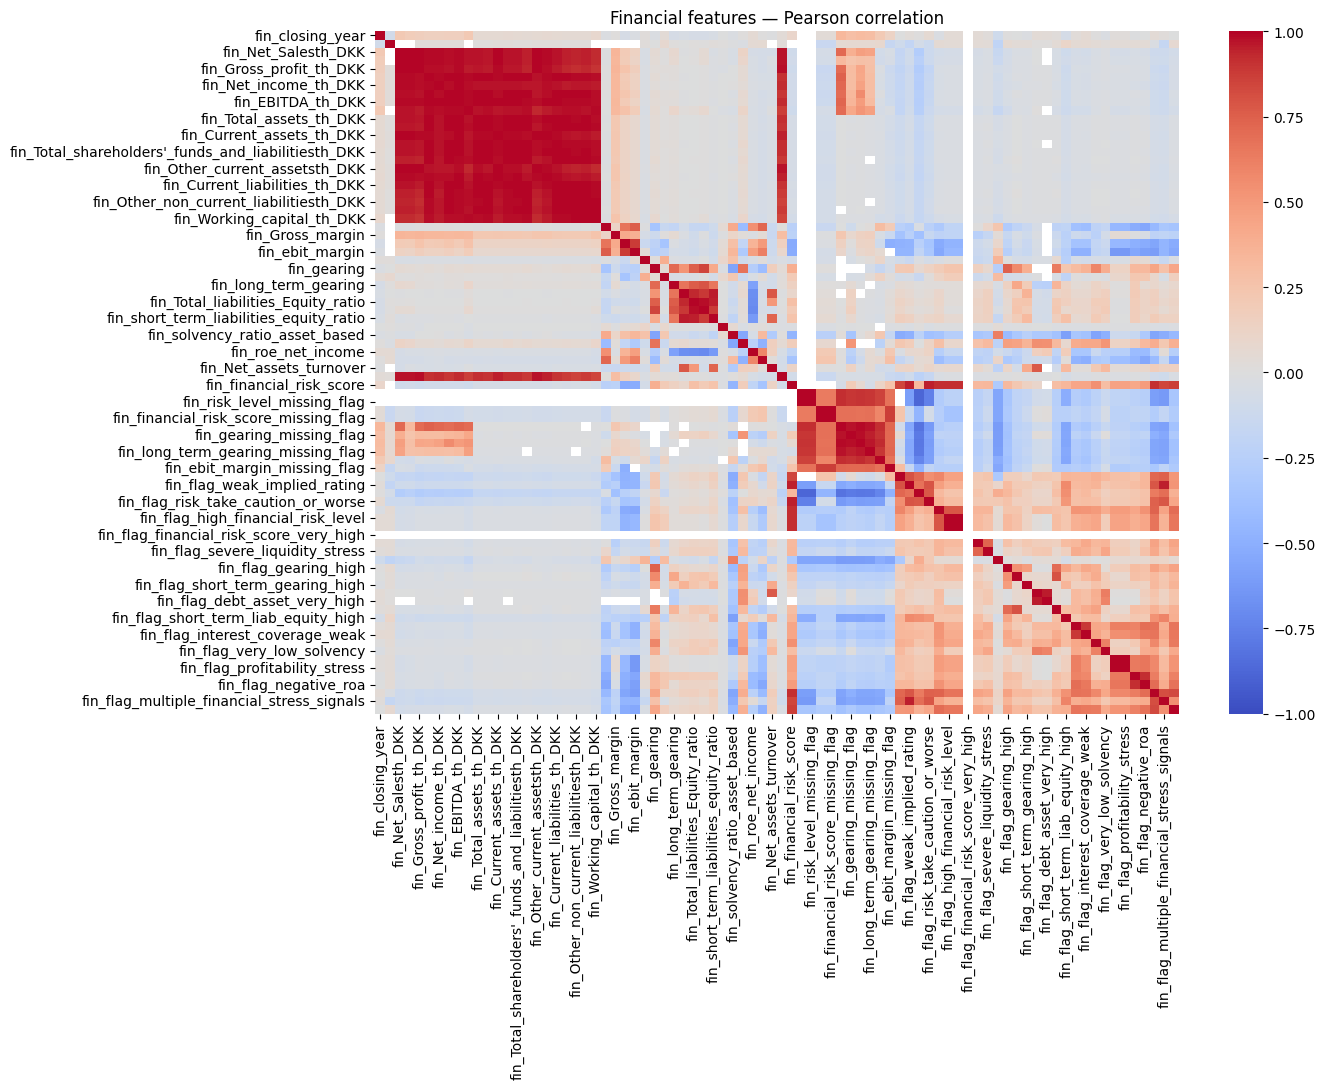

In [104]:
fin_cols = numeric_cols_with_prefix(df_features, "fin_")
plot_corr_heatmap(df_features, fin_cols, "Financial features — Pearson correlation", figsize=(14, 11))
display(high_corr_pairs(df_features, fin_cols, threshold=0.80).head(50))


## ESG features correlation heatmap

This block examines numeric ESG features. High correlations may occur when several ESG dimensions come from the same provider methodology, so the purpose is to identify whether the ESG view contributes distinct signals or repeated versions of the same score.


,feature_1,feature_2,corr,abs_corr
0,esg_esg_overall,esg_esg_industry_adjusted,0.847743,0.847743
1,esg_env_weight,esg_social_weight,-0.801003,0.801003


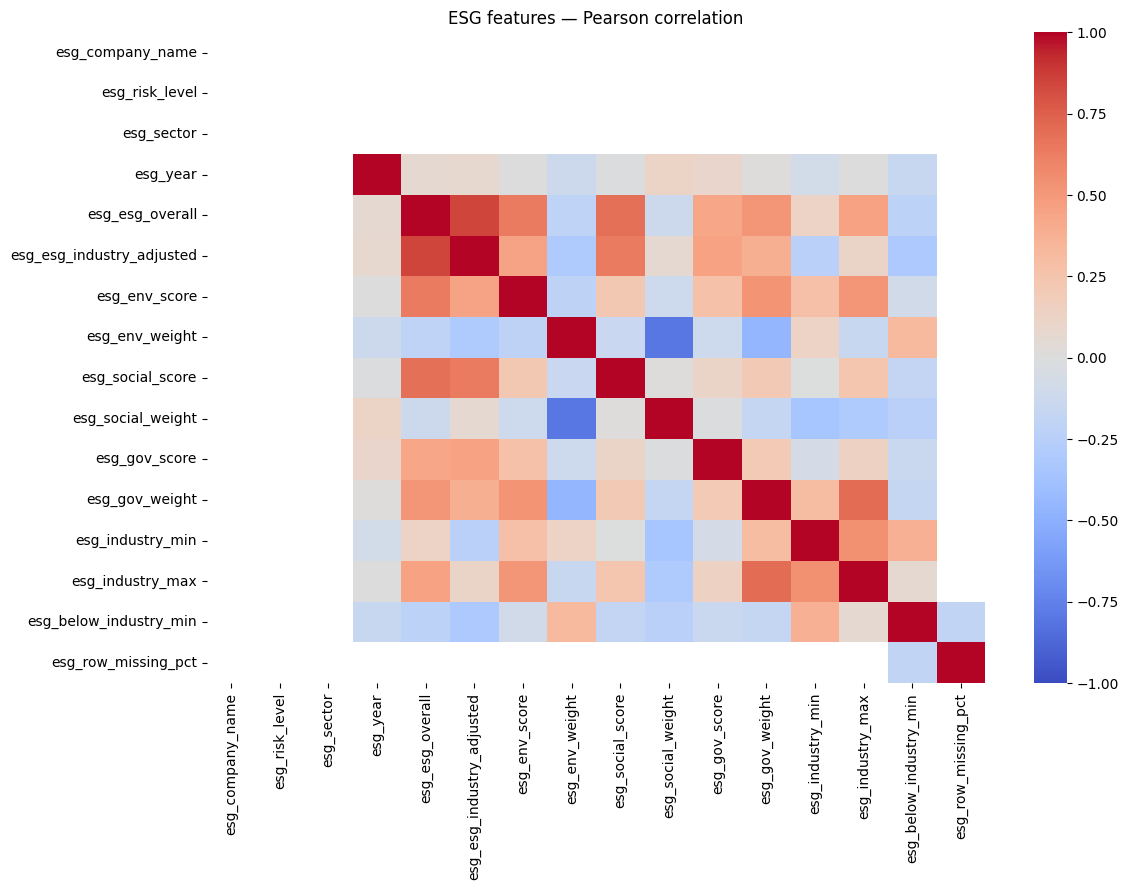

In [105]:
esg_cols = numeric_cols_with_prefix(df_features, "esg_")
plot_corr_heatmap(df_features, esg_cols, "ESG features — Pearson correlation", figsize=(12, 9))
display(high_corr_pairs(df_features, esg_cols, threshold=0.80).head(50))


## News features correlation heatmap

This block examines numeric news features. Count variables and ratio variables can be mechanically related; if high correlations are found, ratios or shares may be preferable to several raw count variables.


,feature_1,feature_2,corr,abs_corr
0,news_article_count,news_positive_count,0.949943,0.949943
1,news_avg_relevance_score,news_max_relevance_score,0.837869,0.837869
2,news_avg_sentiment_score,news_negative_ratio,-0.805203,0.805203


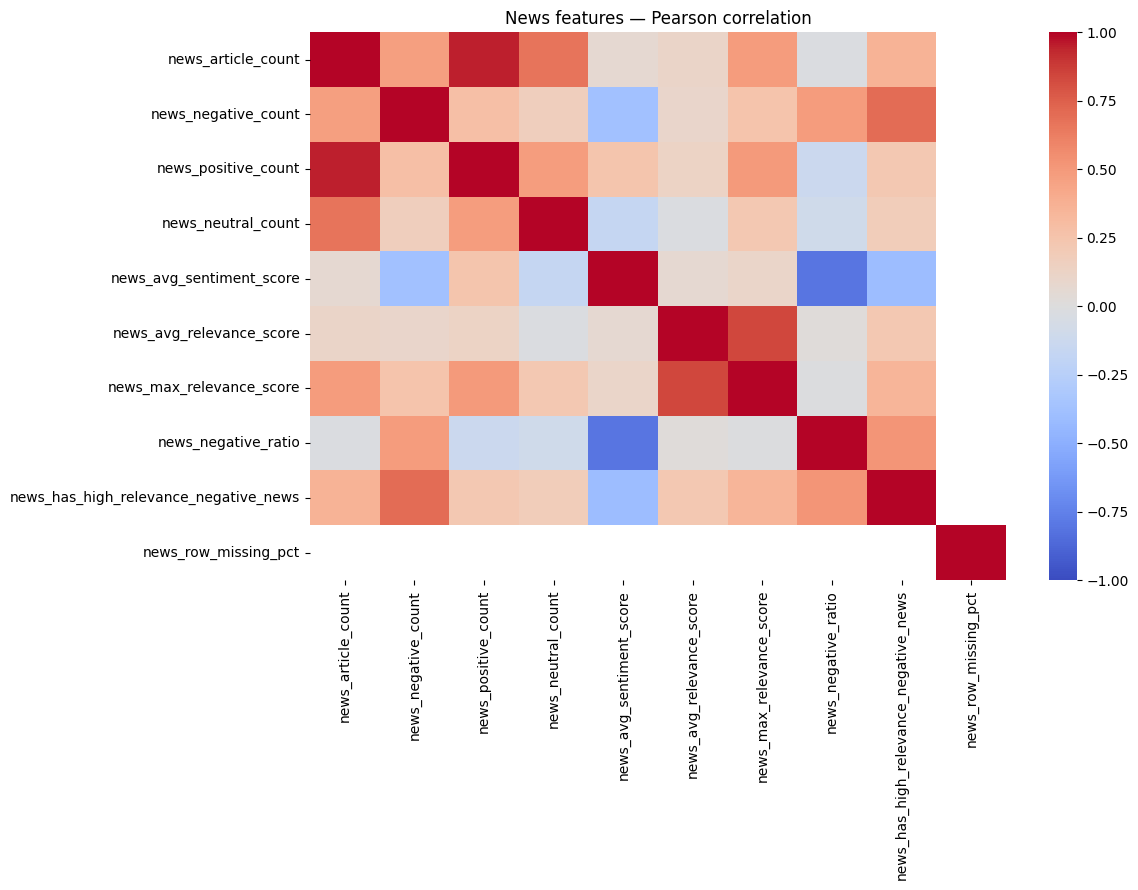

In [106]:
news_cols = numeric_cols_with_prefix(df_features, "news_")
plot_corr_heatmap(df_features, news_cols, "News features — Pearson correlation", figsize=(12, 9))
display(high_corr_pairs(df_features, news_cols, threshold=0.80).head(50))


## Market and stock features correlation heatmap

This block examines market and stock features. Most correlations should be interpreted cautiously because approximately 96.5% of rows have missing market data, and later imputation may create trivially similar values across many rows.


,feature_1,feature_2,corr,abs_corr
0,market_has_stock_view,supplier_is_publicly_listed,1.000000,1.000000
1,Earnings_per_share_DKK,Book_value_per_share_DKK,0.999543,0.999543
2,avg_vol,min_vol,0.994926,0.994926
3,market_beta_1y,market_flag_stock_price_take_caution_or_worse,0.980581,0.980581
4,std_vol,max_vol,0.972308,0.972308
5,avg_vol,max_vol,0.962780,0.962780
6,max_vol,avg_market_cap,0.935899,0.935899
7,max_vol,min_vol,0.935857,0.935857
8,min_vol,avg_market_cap,0.931532,0.931532
9,avg_vol,avg_market_cap,0.931221,0.931221


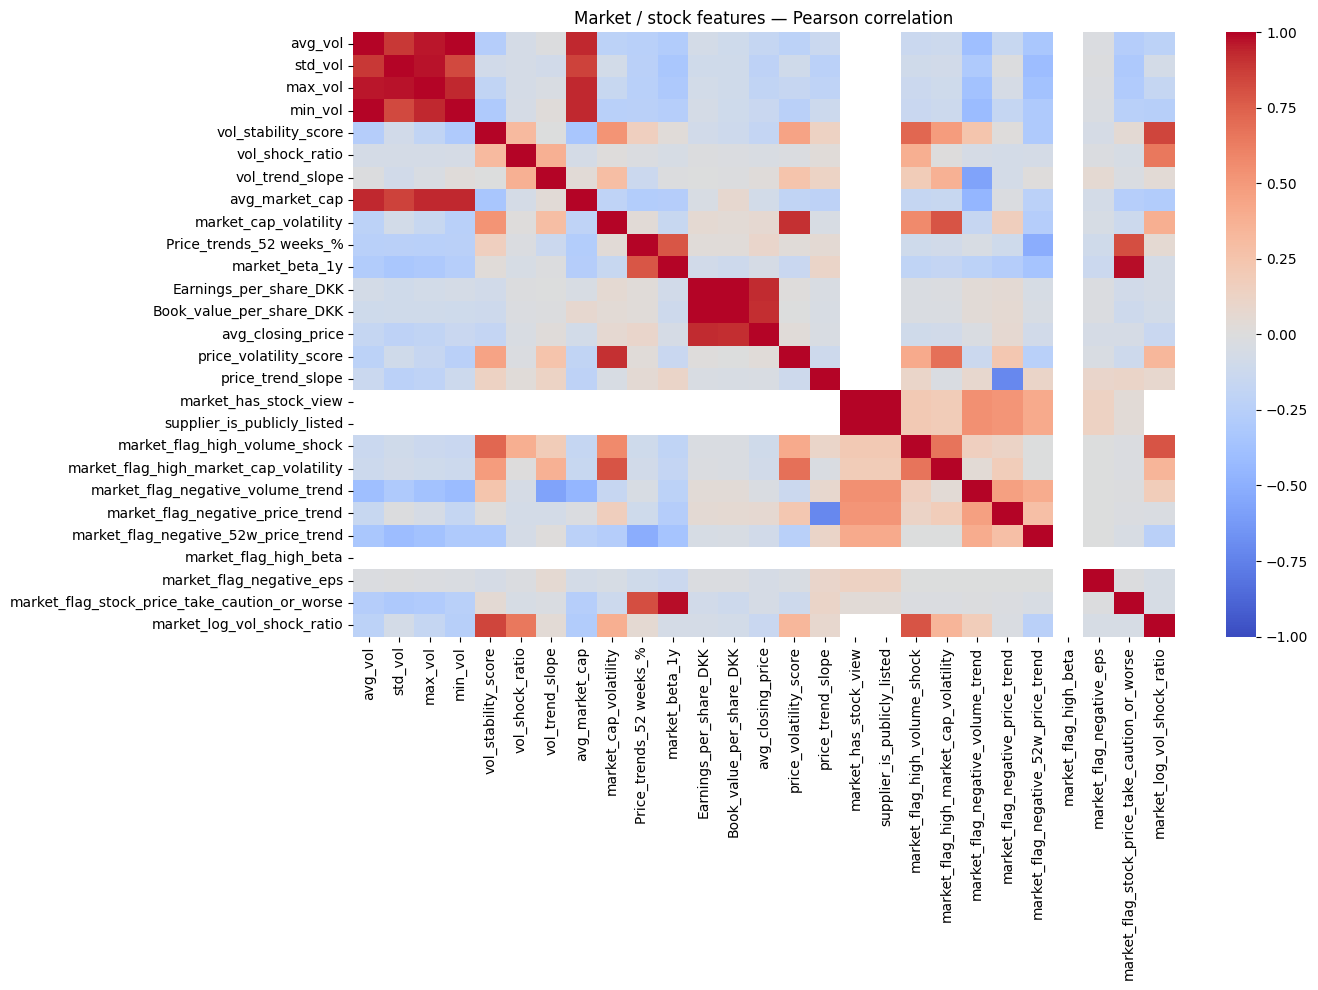

In [107]:
market_cols_for_corr = [
    c for c in df_features.columns
    if (c.startswith("market_") or c in ["supplier_is_publicly_listed", "avg_vol", "std_vol", "max_vol", "min_vol", "vol_stability_score", "vol_shock_ratio", "vol_trend_slope", "avg_market_cap", "market_cap_volatility", "Price_trends_52 weeks_%", "market_beta_1y", "Earnings_per_share_DKK", "Book_value_per_share_DKK", "avg_closing_price", "price_volatility_score", "price_trend_slope"])
    and pd.api.types.is_numeric_dtype(df_features[c])
]
plot_corr_heatmap(df_features, market_cols_for_corr, "Market / stock features — Pearson correlation", figsize=(14, 10))
display(high_corr_pairs(df_features, market_cols_for_corr, threshold=0.80).head(50))


## Contract lifecycle features correlation heatmap

This block examines lifecycle features. Correlation between `years_to_expiry` and `days_until_expiry` is expected, but `is_old_and_near_expiry` is kept because it captures a specific business trigger: maturity plus renewal pressure.


,feature_1,feature_2,corr,abs_corr
0,years_to_expiry,open_ended_contract,0.992752,0.992752


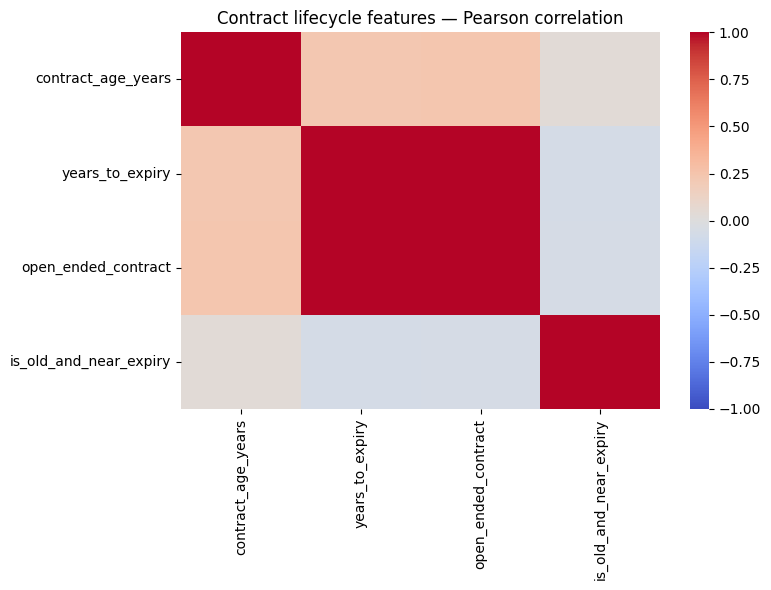

In [108]:
lifecycle_cols = [c for c in ["contract_age_years", "years_to_expiry", "days_until_expiry", "open_ended_contract", "is_old_and_near_expiry"] if c in df_features.columns]
plot_corr_heatmap(df_features, lifecycle_cols, "Contract lifecycle features — Pearson correlation", figsize=(8, 6))
display(high_corr_pairs(df_features, lifecycle_cols, threshold=0.80))


## Cross-view correlation heatmap

This block selects the 35 most variable numeric features across all views. It is designed to catch unexpected inter-view redundancies, such as a macro indicator duplicating country-level supplier structure or a market variable duplicating a financial stress feature.


(<Figure size 1600x1300 with 2 Axes>,
 <Axes: title={'center': 'Cross-view correlation — top 35 most variable numeric features'}>)

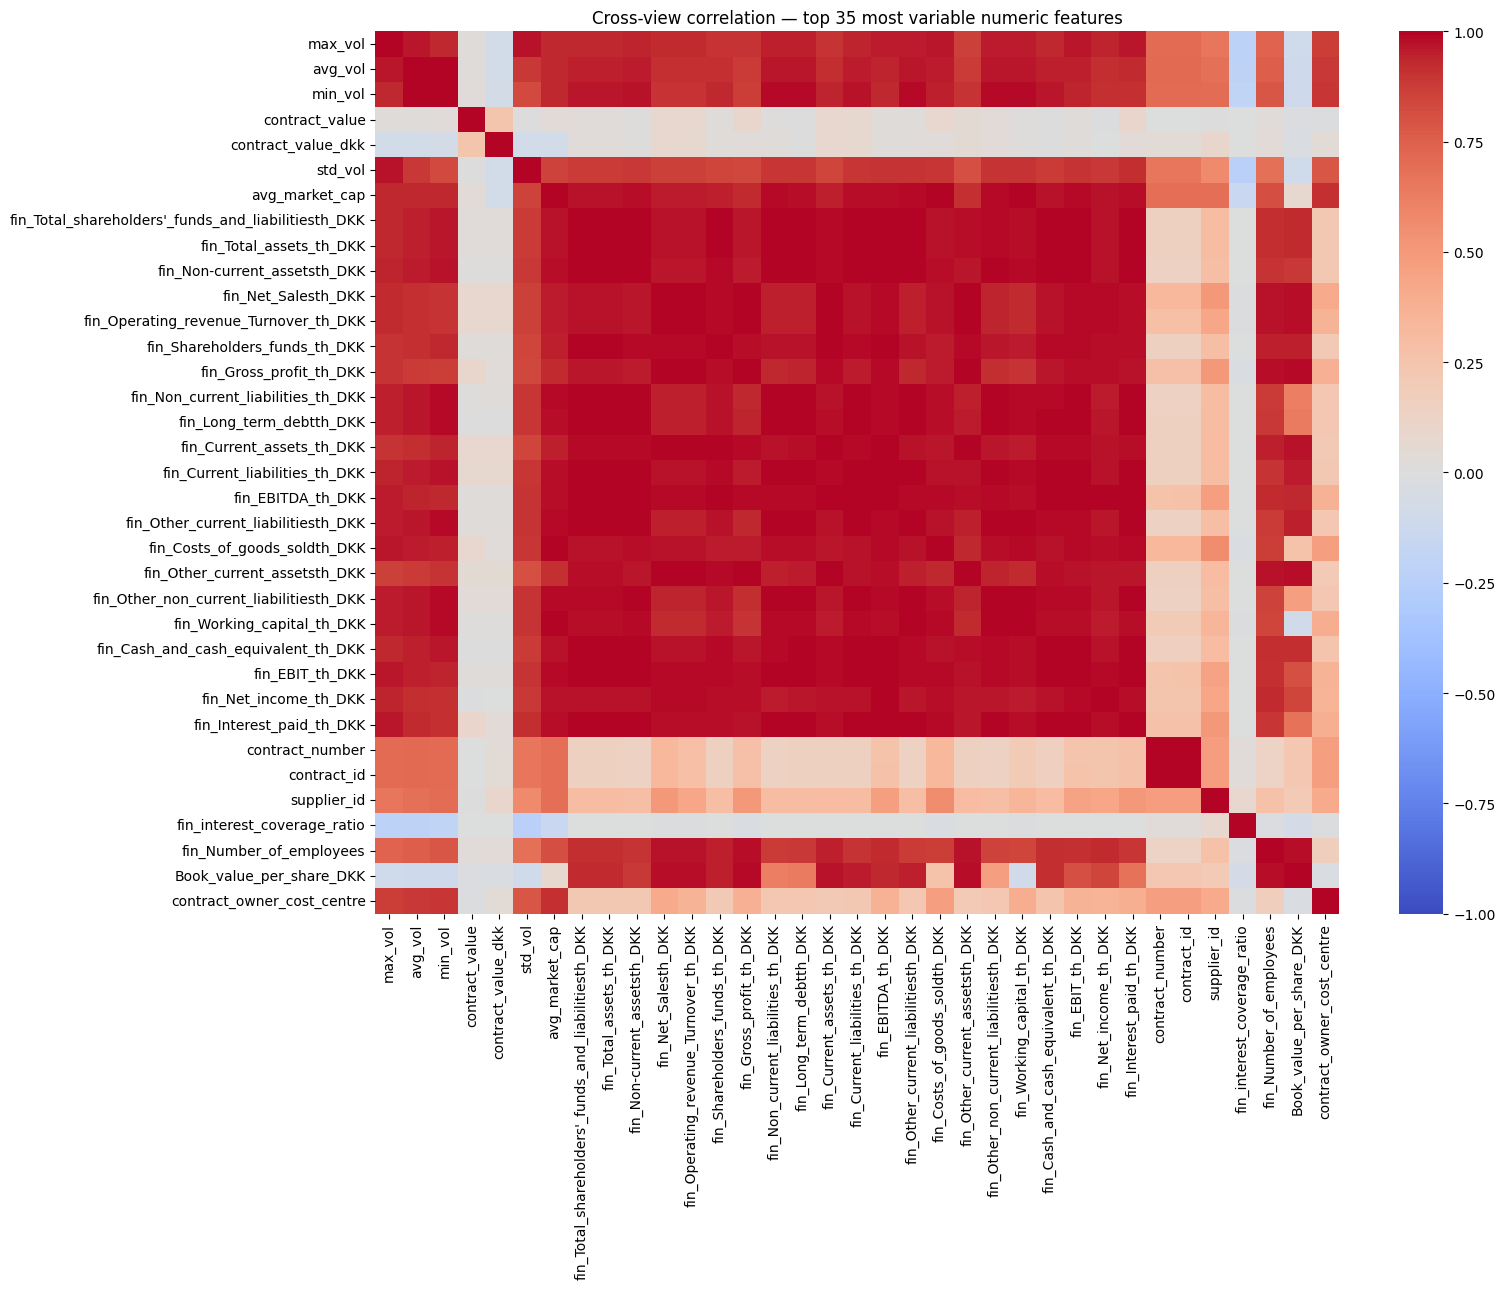

In [109]:
all_numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
top_35_variable_cols = df_features[all_numeric_cols].std(numeric_only=True).sort_values(ascending=False).head(35).index.tolist()
plot_corr_heatmap(df_features, top_35_variable_cols, "Cross-view correlation — top 35 most variable numeric features", figsize=(16, 13))


## High-correlation pair summary table

This is the actionable output. Numeric feature pairs with absolute Pearson correlation at or above 0.80 should be reviewed before Snorkel labeling and neural model training, because redundant features can dilute model attention without adding meaningful information.


In [110]:
all_numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
high_corr_summary = high_corr_pairs(df_features, all_numeric_cols, threshold=0.80)
print(f"Number of high-correlation pairs (|r| >= 0.80): {len(high_corr_summary)}")
display(high_corr_summary.head(100))


Number of high-correlation pairs (|r| >= 0.80): 492


,feature_1,feature_2,corr,abs_corr
0,market_has_stock_view,supplier_is_publicly_listed,1.000000,1.000000
1,fin_closing_year,esg_year,1.000000,1.000000
2,fin_flag_negative_ebit_margin,fin_flag_profitability_stress,1.000000,1.000000
3,fin_flag_high_financial_risk_level,fin_flag_financial_risk_score_high,1.000000,1.000000
4,fin_financial_level_missing_flag,fin_financial_risk_score_missing_flag,1.000000,1.000000
...,...,...,...,...
95,fin_Gross_profit_th_DKK,Book_value_per_share_DKK,0.991983,0.991983
96,fin_EBIT_th_DKK,fin_Costs_of_goods_soldth_DKK,0.991897,0.991897
97,fin_EBIT_th_DKK,fin_Other_current_liabilitiesth_DKK,0.991800,0.991800
98,fin_Gross_margin,gold_y,-0.991528,0.991528


## LPI dataset-relative risk flag

This section engineers a dataset-relative logistics risk indicator from the World Bank Logistics Performance Index (LPI). The commonly cited academic threshold around 3.0 is useful for cross-country comparisons at a global level, but it is not well calibrated to the supplier population in this thesis. Novo Nordisk suppliers are concentrated in Europe and developed Asia, where observed LPI scores are typically much higher than the global average. As a result, a global threshold would rarely activate on the countries that actually appear in the contract portfolio and would therefore add little value to weak supervision.

The engineering decision is to benchmark each supplier country against the empirical LPI distribution observed in the thesis dataset itself. A contract is flagged if its `LPI_Score` falls below the median LPI among supplier-country observations with available data. This produces a relative macro-risk signal that is tailored to the operational environment of the supplier base rather than to the world economy as a whole.


In [111]:
# Dataset-relative macro logistics risk signal based on the supplier-country distribution.
# Threshold source: empirical median LPI in the observed supplier population.

lpi_non_null = df_features["LPI_Score"].dropna()
dataset_median_lpi = float(lpi_non_null.median()) if not lpi_non_null.empty else np.nan

df_features["lpi_below_supplier_median"] = np.where(
    df_features["LPI_Score"].notna() & (df_features["LPI_Score"] < dataset_median_lpi),
    1,
    0,
).astype(int)

print(f"Dataset median LPI_Score across supplier-country observations: {dataset_median_lpi:.4f}")
display(
    df_features[["LPI_Score", "lpi_below_supplier_median"]]
    .drop_duplicates()
    .sort_values("LPI_Score")
    .head(15)
)
print("Flag rate:", df_features["lpi_below_supplier_median"].mean())


Dataset median LPI_Score across supplier-country observations: 4.1000


,LPI_Score,lpi_below_supplier_median
864,3.200000,1
375,3.600000,1
5190,3.605147,1
6056,3.696623,1
867,3.700000,1
16,3.782520,1
638,3.800000,1
1207,3.844475,1
6576,3.847305,1
633,3.885129,1


Flag rate: 0.43440930333659383


## Fixing collinearity between expiry horizon and open-endedness

This section addresses the near-perfect correlation between `years_to_expiry` and `open_ended_contract`. In the joined data, open-ended contracts were represented through a large imputed expiry horizon, which makes `years_to_expiry` behave like a disguised indicator for whether a contract is open-ended. This is problematic because the model would effectively receive the same structural signal twice, inflating the importance of one administrative encoding choice.

The engineering decision is to separate the two concepts. `open_ended_contract` remains the dedicated indicator for indefinite duration, while a new `years_to_expiry_capped` feature captures the remaining time to expiry only for fixed-term contracts. The value is capped at 10 years to preserve ordering while reducing leverage from extreme horizons. Open-ended contracts receive `NaN` in the capped feature so that missingness reflects genuine semantic inapplicability rather than an artificial large number.


In [112]:
# Collinearity fix: preserve expiry signal for fixed-term contracts only.
# Threshold source: modelling choice informed by observed 0.993 correlation with open_ended_contract.

if "years_to_expiry" in df_features.columns:
    fixed_term_mask = df_features["open_ended_contract"].fillna(0).eq(0)

    df_features["years_to_expiry_capped"] = np.where(
        fixed_term_mask,
        np.minimum(df_features["years_to_expiry"], 10),
        np.nan,
    )

    df_features = df_features.drop(columns=["years_to_expiry"], errors="ignore")

print("Contains original years_to_expiry:", "years_to_expiry" in df_features.columns)
print("Contains years_to_expiry_capped:", "years_to_expiry_capped" in df_features.columns)
display(
    df_features[
        [c for c in ["open_ended_contract", "years_to_expiry_capped", "days_until_expiry"] if c in df_features.columns]
    ].head(10)
)


Contains original years_to_expiry: False
Contains years_to_expiry_capped: True


,open_ended_contract,years_to_expiry_capped
0,0,9.0
1,0,8.0
2,0,7.0
3,0,6.0
4,0,5.0
5,0,4.0
6,0,3.0
7,0,2.0
8,0,10.0
9,0,10.0


## Supplier contract fragmentation feature

This feature captures organizational fragmentation at the supplier level. Suppliers managing many separate contracts at the same time may face higher coordination costs, more touchpoints across teams, and greater renewal complexity. In a renegotiation setting, that fragmentation can increase the likelihood that at least some contracts require review, consolidation, or updated commercial terms.

In [113]:
df_features["contracts_per_supplier"] = df_features.groupby("supplier_id")["contract_id"].transform("nunique")

## Feature Pruning

This block provides a single, transparent place to remove features before saving the final feature matrix. The goal is not to hide modelling choices, but to make them explicit and reproducible. Three pruning rules are applied in sequence: manual removals based on domain and earlier correlation findings, automatic correlation-based pruning for near-duplicate numeric features, and missingness-based pruning for columns that provide almost no usable information.

All rules are hardcoded at the top of the block so that feature selection decisions can be audited by a thesis examiner or reproduced later in the project pipeline. Every removed feature is logged and printed. This makes the pruning stage the correct place to adjust the final feature set; earlier feature engineering cells should remain focused on signal construction rather than on final inclusion or exclusion decisions.


## Protected Features for Thesis Integrity

Contract-core columns form the structural foundation of the dataset. They describe what the contract **is**—its identity, lifecycle, terms, organizational context, and supplier-country setting—rather than merely what external signals surround it. This distinction matters directly for the thesis: Stage 2 few-shot adaptation relies on the model seeing the structural pattern that makes a Logistics contract different from a Raw Materials or Packaging contract. If such columns were removed simply because they are highly correlated with another lifecycle or identifier field, the pipeline would lose the very basis for department-specific adaptation.

For that reason, the protected feature list below is intentionally broader than a normal pruning exception list. It includes contract-core variables, Snorkel dependencies, grouping keys, and label columns that must survive automated correlation pruning regardless of their statistical relationship to neighboring features. In methodological terms, this is a categorical protection rule: structural contract variables are part of the thesis design and are therefore not eligible for automatic removal.


## Data Leakage Check Before Pruning
Before pruning is applied, the notebook performs a leakage screen against the gold-label columns. In a multi-view feature table, it is possible for one view to inadvertently encode label information if joins, temporal filters, or imputations interact in unexpected ways. A raw feature that is almost perfectly correlated with a human-reviewed gold label is therefore not a welcome strong predictor; it is a leakage suspect until proven otherwise.

At the same time, this screening must not break the weak-supervision layer. Some columns are explicit dependencies of downstream Snorkel labeling functions, and removing them automatically would cause those labeling functions to silently abstain on all rows. The leakage screen therefore only escalates a feature into manual removal when it is highly correlated with `gold_y`, is not thesis-protected, and is not required by the labeling-function layer. This preserves the contractual interface between feature engineering and weak supervision while still surfacing genuine leakage risks.


In [114]:
# -----------------------------
# Data leakage screening
# -----------------------------
LEAKAGE_CORR_THRESHOLD = 0.90
LF_DEPENDENCY_COLS = [
    "esg_esg_overall",
    "fin_flag_negative_profit_margin",
    "fin_flag_negative_ebit_margin",
    "years_to_expiry",
    "open_ended_contract",
    "contracts_per_supplier",
]
THESIS_PROTECTED_FOR_LEAKAGE = {
    "open_ended_contract",
    "contracts_per_supplier", "years_to_expiry_capped", "esg_esg_industry_adjusted",
    "LPI_Score", "PPI_Value", "lpi_below_supplier_median", "is_old_and_near_expiry",
    "esg_below_industry_min", "supplier_is_publicly_listed", "payment_terms", "incoterms",
    "contract_age_years", "expiry_pressure_bucket", "contract_id", "supplier_id",
    "department", "observation_year", "gold_y", "target_renegotiate", "renegotiation_prob"
}

label_candidates = [c for c in ["gold_y", "target_renegotiate", "renegotiation_prob"] if c in df_features.columns]
numeric_cols_for_leakage = df_features.select_dtypes(include=[np.number, "bool"]).columns.tolist()
numeric_feature_candidates = [c for c in numeric_cols_for_leakage if c not in label_candidates]

leakage_rows = []
for feature in numeric_feature_candidates:
    for label_col in [c for c in ["gold_y", "target_renegotiate"] if c in df_features.columns]:
        pair_df = df_features[[feature, label_col]].dropna()
        if len(pair_df) < 2:
            continue
        corr_val = pair_df[feature].corr(pair_df[label_col])
        if pd.notna(corr_val) and abs(corr_val) >= LEAKAGE_CORR_THRESHOLD:
            leakage_rows.append(
                {
                    "feature": feature,
                    "label_col": label_col,
                    "abs_corr": float(abs(corr_val)),
                    "corr_value": float(corr_val),
                    "is_thesis_protected": feature in THESIS_PROTECTED_FOR_LEAKAGE,
                    "is_lf_dependency": feature in LF_DEPENDENCY_COLS,
                }
            )

df_leakage_candidates = pd.DataFrame(leakage_rows)
if not df_leakage_candidates.empty:
    df_leakage_candidates = (
        df_leakage_candidates
        .sort_values(["abs_corr", "feature"], ascending=[False, True])
        .reset_index(drop=True)
    )

print("Potential leakage candidates (|corr| >= 0.90 against gold labels)")
print("-" * 70)
if df_leakage_candidates.empty:
    print("No numeric feature exceeded the leakage threshold.")
else:
    display(df_leakage_candidates)

LEAKAGE_MANUAL_REMOVALS = []
if not df_leakage_candidates.empty:
    leakage_gold = df_leakage_candidates.loc[df_leakage_candidates["label_col"] == "gold_y"].copy()
    leakage_gold = leakage_gold.loc[
        (leakage_gold["abs_corr"] >= LEAKAGE_CORR_THRESHOLD)
        & (~leakage_gold["feature"].isin(THESIS_PROTECTED_FOR_LEAKAGE))
        & (~leakage_gold["feature"].isin(LF_DEPENDENCY_COLS))
    ]
    LEAKAGE_MANUAL_REMOVALS = sorted(leakage_gold["feature"].unique().tolist())

print("Leakage-driven manual removals:", LEAKAGE_MANUAL_REMOVALS)


Potential leakage candidates (|corr| >= 0.90 against gold labels)
----------------------------------------------------------------------


/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,feature,label_col,abs_corr,corr_value,is_thesis_protected,is_lf_dependency
0,esg_esg_overall,gold_y,1.000000,1.000000,False,True
1,fin_Gross_margin,gold_y,0.991528,-0.991528,False,False
2,fin_Working_capital_th_DKK,gold_y,0.959000,0.959000,False,False
3,fin_Costs_of_goods_soldth_DKK,gold_y,0.933972,0.933972,False,False


Leakage-driven manual removals: ['fin_Costs_of_goods_soldth_DKK', 'fin_Gross_margin', 'fin_Working_capital_th_DKK']


# Feature Pruning: Overview and Protected Features

This section applies three transparent, sequential pruning rules to the engineered feature table before it is saved for downstream use. The objective is not to maximize sparsity for its own sake, but to reduce redundancy, remove leakage candidates, and preserve a feature space that remains interpretable and defensible in a thesis setting. The pruning logic is therefore explicitly rule-based rather than hidden inside model training.

The **THESIS_PROTECTED_FEATURES** list is the primary safeguard in this section. Any feature in that list is treated as structurally necessary for downstream steps and cannot be removed by the automatic correlation-pruning rule or the missingness-pruning rule. These protected variables include contract-core descriptors, grouping variables, label columns, and other fields that are directly required for later pipeline stages. If one of these features should ever be removed, that decision must be made explicitly through the manual Rule 1 list rather than accidentally through an automated threshold.

For reproducibility, every removal decision is written to `Data/processed/feature_pruning_audit.csv`. This audit trail makes the pruning step reviewable in the thesis without requiring the notebook to be re-run.

In [115]:
# View assignment helper reused for post-pruning summary.
if "assign_view" not in globals():
    def assign_view(col):
        if col.startswith("fin_"):
            return "financial"
        elif col.startswith("esg_"):
            return "esg"
        elif col.startswith("news_"):
            return "news"
        elif col in ["LPI_Score", "Customs", "Infrastructure", "International_Shipments",
                     "Logistics_Competence", "Tracking_Tracing", "Timeliness", "PPI_Value"]:
            return "macro_logistics"
        elif col in ["avg_vol", "std_vol", "max_vol", "min_vol", "vol_stability_score",
                     "vol_shock_ratio", "vol_trend_slope", "avg_market_cap",
                     "market_cap_volatility", "Price_trends_52 weeks_%", "market_beta_1y",
                     "Earnings_per_share_DKK", "Book_value_per_share_DKK", "avg_closing_price",
                     "price_volatility_score", "price_trend_slope", "market_log_vol_shock_ratio",
                     "supplier_is_publicly_listed", "market_has_stock_view"]:
            return "market_stocks"
        elif col in ["contract_id", "contract_number", "contract_name", "contract_status", "contract_type",
                     "nn_contract_type", "contract_commodity", "start_date", "expiration_date", "start_year",
                     "expiry_year", "end_year", "start_year_capped", "observation_year", "contract_age_years",
                     "days_until_expiry", "years_to_expiry_capped", "open_ended_contract", "is_old_and_near_expiry",
                     "expiry_pressure_bucket", "payment_terms", "incoterms", "contract_currency_code",
                     "contract_value", "contract_value_dkk", "has_environmental_appendix"]:
            return "contract_core"
        elif col in ["supplier_id", "supplier_number", "supplier_display_name", "department", "team", "unit",
                     "company_country", "company_country_clean", "contracts_per_supplier", "supplier_sector"]:
            return "supplier_org"
        elif col in ["target_renegotiate", "renegotiation_prob", "gold_y", "gold_department",
                     "lf_yes_votes", "lf_no_votes", "lf_abstain_votes"]:
            return "labels_and_votes"
        return "other"

removal_log = []
total_before = len(df_features.columns)

features_before_pruning = list(df_features.columns)
features_before_by_view = (
    pd.Series(features_before_pruning, name="feature")
    .map(assign_view)
    .value_counts()
    .rename_axis("view")
    .reset_index(name="features_before_pruning")
)

THESIS_PROTECTED_FEATURES = [
    # Contract identity
    "contract_id", "contract_name", "contract_status", "contract_type",
    "nn_contract_type", "contract_commodity",
    # Contract lifecycle
    "start_date", "expiration_date", "start_year", "expiry_year", "end_year", "start_year_capped",
    "observation_year", "contract_age_years", "years_to_expiry_capped",
    "open_ended_contract", "is_old_and_near_expiry", "expiry_pressure_bucket",
    # Contract terms
    "payment_terms", "incoterms", "contract_currency_code", "contract_value", "contract_value_dkk",
    # Supplier and organizational
    "supplier_id", "supplier_number", "supplier_display_name", "department", "team", "unit",
    "company_country", "company_country_clean", "contracts_per_supplier", "supplier_sector",
    # Macro logistics signals
    "LPI_Score", "PPI_Value", "lpi_below_supplier_median",
    # Existing stage-2 structural features
    "supplier_is_publicly_listed", "esg_below_industry_min", "open_ended_contract",
    "contracts_per_supplier", "years_to_expiry_capped", "esg_esg_industry_adjusted",
    # Snorkel LF dependencies
    "fin_flag_negative_ebit_margin", "fin_total_stress_flags", "fin_implied_rating_ordinal",
    # Label columns
    "target_renegotiate", "renegotiation_prob", "gold_y", "gold_department",
    # Snorkel vote metadata
    "lf_yes_votes", "lf_no_votes", "lf_abstain_votes",
    # Optional grouping helpers if present
    "group_col", "department_col",
]
THESIS_PROTECTED_FEATURES = [c for c in THESIS_PROTECTED_FEATURES if c in df_features.columns]
PROTECTED_FEATURES = set(THESIS_PROTECTED_FEATURES) | {c for c in LF_DEPENDENCY_COLS if c in df_features.columns}

## Rule 1 — Hardcoded Manual Removals

Rule 1 targets two categories of features that should not remain in the modeling dataset even if they survive later statistical screens. The first category is **raw absolute financial balance-sheet values denominated in DKK**. These variables are removed because they are scale-dependent and therefore difficult to compare across suppliers of very different size. A supplier with billions of DKK in assets and a supplier with millions of DKK in assets can have very different absolute accounting magnitudes while exhibiting structurally similar financial risk. For cross-company prediction and cross-department adaptation, ratio-based signals are therefore preferred over raw size-heavy accounting line items.

The second category is **features flagged by the leakage screen as near-perfectly correlated with the gold label**. A raw feature that is almost perfectly aligned with a human-reviewed target is more likely to be a join artifact or leakage pathway than a legitimate predictive signal. Such columns are removed before any correlation-based pruning occurs. Rule 1 also incorporates any features placed in `LEAKAGE_MANUAL_REMOVALS` by the upstream leakage screening cell.

In [116]:
# RULE 1 — Hardcoded manual removals
raw_dkk_financial_cols = sorted(
    [c for c in df_features.columns if c.startswith("fin_") and c.endswith("_th_DKK")]
)

MANUAL_REMOVALS = raw_dkk_financial_cols + [
    "market_has_stock_view",    # redundant with supplier_is_publicly_listed
]

MANUAL_REMOVALS.extend([c for c in LEAKAGE_MANUAL_REMOVALS if c not in MANUAL_REMOVALS])

manual_removed = [c for c in MANUAL_REMOVALS if c in df_features.columns]
if manual_removed:
    df_features = df_features.drop(columns=manual_removed, errors="ignore")
    for c in manual_removed:
        reason = "Hardcoded manual removal based on domain and prior audit."
        priority = "manual"
        if c in LEAKAGE_MANUAL_REMOVALS:
            reason = "Manual removal triggered by leakage screen: abs(corr with gold_y) exceeded 0.90 and feature was neither thesis-protected nor required by a Snorkel labeling function."
        removal_log.append(
            {
                "feature": c,
                "dropped_by_rule": "RULE1",
                "correlated_with": "",
                "correlation_value": np.nan,
                "priority_level_used": priority,
                "reason": reason,
            }
        )

print(f"Rule 1 removed {len(set(manual_removed))} features.")
print(sorted(set(manual_removed)) if manual_removed else "None")

Rule 1 removed 16 features.
['fin_Cash_and_cash_equivalent_th_DKK', 'fin_Costs_of_goods_soldth_DKK', 'fin_Current_assets_th_DKK', 'fin_Current_liabilities_th_DKK', 'fin_EBITDA_th_DKK', 'fin_EBIT_th_DKK', 'fin_Gross_margin', 'fin_Gross_profit_th_DKK', 'fin_Interest_paid_th_DKK', 'fin_Net_income_th_DKK', 'fin_Non_current_liabilities_th_DKK', 'fin_Operating_revenue_Turnover_th_DKK', 'fin_Shareholders_funds_th_DKK', 'fin_Total_assets_th_DKK', 'fin_Working_capital_th_DKK', 'market_has_stock_view']


## Rule 2 — Domain-Priority Correlation Pruning

Rule 2 identifies pairs of features whose absolute Pearson correlation is at or above `CORR_PRUNE_THRESHOLD` and removes one feature from each pair using a domain-priority ordering. The goal is not merely to reduce dimensionality, but to preserve the **more interpretable and transferable** feature whenever two columns are effectively encoding the same signal.

The priority order is as follows. **Priority 1** keeps thesis-protected features. **Priority 2** keeps engineered binary flags over raw continuous inputs, because a flag encodes a concrete and testable hypothesis while the raw measurement is often scale-sensitive and duplicated elsewhere. **Priority 3** keeps normalized ratio-style variables over raw absolute values, because ratio features are more comparable across firms of different size and therefore better suited to cross-department generalization in MAML. **Priority 4** uses lower missingness as a tie-breaker when neither feature has a clear conceptual advantage.

This ordering makes the pruning logic academically defensible. Highly correlated features are not being dropped arbitrarily or alphabetically; instead, the retained feature is chosen because it is better aligned with interpretability, robustness, and the thesis objective of few-shot adaptation across departments.

In [117]:
# RULE 2 — Automatic correlation-based pruning
CORR_PRUNE_THRESHOLD = 0.95

def _is_engineered_flag(name: str) -> bool:
    return (
        name.endswith("_flag")
        or name.startswith("fin_flag_")
        or name.startswith("market_flag_")
        or name.startswith("news_flag_")
        or name.startswith("esg_flag_")
    )

def _is_ratio_like(name: str) -> bool:
    lowered = name.lower()
    tokens = ("ratio", "margin", "score", "pct", "rate", "per")
    return any(tok in lowered for tok in tokens)

def _is_scale_heavy_raw(name: str) -> bool:
    lowered = name.lower()
    return name.endswith("_th_DKK") or any(tok in lowered for tok in ["volume", "assets", "revenue", "sales", "income", "market_cap", "price"])

def _missing_pct(series: pd.Series) -> float:
    return float(series.isna().mean() * 100)

def _decide_keep_drop(f1: str, f2: str, working_df: pd.DataFrame) -> tuple[str, str, int, str]:
    # Priority 1 — thesis-protected features
    f1_protected = f1 in PROTECTED_FEATURES
    f2_protected = f2 in PROTECTED_FEATURES
    if f1_protected and not f2_protected:
        return f1, f2, 1, "Protected thesis feature retained over correlated partner."
    if f2_protected and not f1_protected:
        return f2, f1, 1, "Protected thesis feature retained over correlated partner."

    # Priority 2 — engineered binary flags
    f1_flag = _is_engineered_flag(f1)
    f2_flag = _is_engineered_flag(f2)
    if f1_flag and not f2_flag:
        return f1, f2, 2, "Engineered binary flag retained over raw continuous feature."
    if f2_flag and not f1_flag:
        return f2, f1, 2, "Engineered binary flag retained over raw continuous feature."

    # Priority 3 — normalized ratio features over scale-heavy raw values
    f1_ratio = _is_ratio_like(f1)
    f2_ratio = _is_ratio_like(f2)
    f1_raw = _is_scale_heavy_raw(f1)
    f2_raw = _is_scale_heavy_raw(f2)
    if f1_ratio and f2_raw and not (f2_ratio and f1_raw):
        return f1, f2, 3, "Ratio-like feature retained over scale-heavy raw measurement."
    if f2_ratio and f1_raw and not (f1_ratio and f2_raw):
        return f2, f1, 3, "Ratio-like feature retained over scale-heavy raw measurement."

    # Priority 4 — lower missingness retained
    miss1 = _missing_pct(working_df[f1]) if f1 in working_df.columns else np.inf
    miss2 = _missing_pct(working_df[f2]) if f2 in working_df.columns else np.inf
    if miss1 < miss2:
        return f1, f2, 4, "Lower-missingness feature retained as tie-breaker."
    if miss2 < miss1:
        return f2, f1, 4, "Lower-missingness feature retained as tie-breaker."

    # Final deterministic tie-break if missingness is equal
    keep = sorted([f1, f2])[0]
    drop = f2 if keep == f1 else f1
    return keep, drop, 4, "Equal missingness; deterministic tie-break applied after priority rules."

corr_removed = []
if "high_corr_summary" in globals() and isinstance(high_corr_summary, pd.DataFrame) and not high_corr_summary.empty:
    eligible_pairs = high_corr_summary.loc[high_corr_summary["abs_corr"] >= CORR_PRUNE_THRESHOLD].copy()

    for _, row in eligible_pairs.iterrows():
        f1 = row["feature_1"]
        f2 = row["feature_2"]
        corr_val = float(row["abs_corr"])

        if f1 not in df_features.columns or f2 not in df_features.columns:
            continue

        # Absolute protected-feature override: short-circuit before any other priority logic.
        f1_protected = f1 in PROTECTED_FEATURES
        f2_protected = f2 in PROTECTED_FEATURES
        if f1_protected and not f2_protected:
            keep, drop, priority_level, reason = (
                f1,
                f2,
                1,
                "Protected thesis feature retained over correlated partner.",
            )
        elif f2_protected and not f1_protected:
            keep, drop, priority_level, reason = (
                f2,
                f1,
                1,
                "Protected thesis feature retained over correlated partner.",
            )
        elif f1_protected and f2_protected:
            continue
        else:
            keep, drop, priority_level, reason = _decide_keep_drop(f1, f2, df_features)

        if drop in PROTECTED_FEATURES and keep not in PROTECTED_FEATURES:
            keep, drop, priority_level, reason = drop, keep, 1, "Protected thesis feature retained over correlated partner."

        if drop not in df_features.columns or keep not in df_features.columns:
            continue

        df_features = df_features.drop(columns=[drop], errors="ignore")
        corr_removed.append(drop)
        removal_log.append(
            {
                "feature": drop,
                "dropped_by_rule": "RULE2",
                "correlated_with": keep,
                "correlation_value": corr_val,
                "priority_level_used": priority_level,
                "reason": reason,
            }
        )

corr_removed = sorted(set(corr_removed))

print(f"Rule 2 removed {len(set(corr_removed))} features.")

Rule 2 removed 29 features.


In [118]:
missing_protected_after_rule2 = [c for c in THESIS_PROTECTED_FEATURES if c not in df_features.columns]
if missing_protected_after_rule2:
    raise ValueError(f"Protected feature missing after Rule 2 pruning: {missing_protected_after_rule2[0]}")

## Rule 3 — Missingness-Based Pruning

Rule 3 removes features whose missingness exceeds `MISSING_PRUNE_THRESHOLD`. At this level of sparsity, a feature cannot contribute stable signal to either the Snorkel labeling functions or the downstream neural model. In practice, imputing a column that is more than 99 percent missing replaces genuine variation with an almost constant placeholder, which introduces more noise than information.

This rule is especially relevant for partially joined views. For example, ESG metadata columns such as `esg_company_name`, `esg_risk_level`, and `esg_sector` are expected to be removed because the ESG view is only available for a subset of suppliers. The rule therefore acts as a final quality filter that removes columns whose observed coverage is too low to support meaningful inference.

In [119]:
# RULE 3 — Missingness-based pruning
MISSING_PRUNE_THRESHOLD = 99.0

missing_pct = df_features.isna().mean() * 100
missing_removed = sorted(
    [
        c for c in missing_pct.index
        if missing_pct.loc[c] > MISSING_PRUNE_THRESHOLD and c not in PROTECTED_FEATURES
    ]
)

if missing_removed:
    df_features = df_features.drop(columns=missing_removed, errors="ignore")
    for c in missing_removed:
        removal_log.append(
            {
                "feature": c,
                "dropped_by_rule": "RULE3",
                "correlated_with": "",
                "correlation_value": np.nan,
                "priority_level_used": "missing_threshold",
                "reason": f"Feature exceeded the missingness threshold of {MISSING_PRUNE_THRESHOLD}%.",
            }
        )

print(f"Rule 3 removed {len(set(missing_removed))} features.")
print(sorted(set(missing_removed)) if missing_removed else "None")

Rule 3 removed 3 features.
['esg_company_name', 'esg_risk_level', 'esg_sector']


## Pruning Summary and Audit Table

The following cell prints a complete audit of every feature-removal decision made by the three pruning rules. This audit table is also saved to disk so that any reviewer can inspect the full set of pruning decisions without re-running the notebook. This is important for thesis transparency: pruning choices can materially change the final feature space, so each decision should be observable and reproducible.

The audit table records the following information for each removed feature: `feature`, `dropped_by_rule`, `correlated_with`, `correlation_value`, `priority_level_used`, and `reason`. Together, these columns show not just what was removed, but also which rule removed it and why.

In [120]:
# Save and display pruning audit
df_pruning_audit = pd.DataFrame(removal_log)
if not df_pruning_audit.empty:
    df_pruning_audit = (
        df_pruning_audit
        .drop_duplicates()
        .sort_values(["dropped_by_rule", "feature", "correlated_with"])
        .reset_index(drop=True)
    )
else:
    df_pruning_audit = pd.DataFrame(
        columns=[
            "feature",
            "dropped_by_rule",
            "correlated_with",
            "correlation_value",
            "priority_level_used",
            "reason",
        ]
    )

audit_output_path = DATA_PROCESSED / "feature_pruning_audit.csv"
df_pruning_audit.to_csv(audit_output_path, index=False)

# Summary
total_after = len(df_features.columns)

print("Feature pruning summary")
print("-" * 40)
print(f"Total features before pruning: {total_before}")
print(f"Rule 1 removals: {len(set(manual_removed))}")
print(f"Rule 2 removals: {len(set(corr_removed))}")
print(f"Rule 3 removals: {len(set(missing_removed))}")
print(f"Total features after pruning: {total_after}")
print(f"Final output shape: {df_features.shape}")

print("\nRule 1 removed features:")
print(sorted(set(manual_removed)) if manual_removed else "None")

print("\nRule 2 removed features:")
print(sorted(set(corr_removed)) if corr_removed else "None")

print("\nRule 3 removed features:")
print(sorted(set(missing_removed)) if missing_removed else "None")

print("\nSaved pruning audit to:", audit_output_path)
display(df_pruning_audit)

Feature pruning summary
----------------------------------------
Total features before pruning: 205
Rule 1 removals: 16
Rule 2 removals: 29
Rule 3 removals: 3
Total features after pruning: 157
Final output shape: (9201, 157)

Rule 1 removed features:
['fin_Cash_and_cash_equivalent_th_DKK', 'fin_Costs_of_goods_soldth_DKK', 'fin_Current_assets_th_DKK', 'fin_Current_liabilities_th_DKK', 'fin_EBITDA_th_DKK', 'fin_EBIT_th_DKK', 'fin_Gross_margin', 'fin_Gross_profit_th_DKK', 'fin_Interest_paid_th_DKK', 'fin_Net_income_th_DKK', 'fin_Non_current_liabilities_th_DKK', 'fin_Operating_revenue_Turnover_th_DKK', 'fin_Shareholders_funds_th_DKK', 'fin_Total_assets_th_DKK', 'fin_Working_capital_th_DKK', 'market_has_stock_view']

Rule 2 removed features:
['Book_value_per_share_DKK', 'Logistics_Competence', 'Year', 'avg_market_cap', 'contract_number', 'esg_year', 'fin_Long_term_debtth_DKK', 'fin_Net_Salesth_DKK', 'fin_Non-current_assetsth_DKK', 'fin_Other_current_assetsth_DKK', 'fin_Other_current_liabili

,feature,dropped_by_rule,correlated_with,correlation_value,priority_level_used,reason
0,fin_Cash_and_cash_equivalent_th_DKK,RULE1,,NaN,manual,Hardcoded manual removal based on domain and p...
1,fin_Costs_of_goods_soldth_DKK,RULE1,,NaN,manual,Manual removal triggered by leakage screen: ab...
2,fin_Current_assets_th_DKK,RULE1,,NaN,manual,Hardcoded manual removal based on domain and p...
3,fin_Current_liabilities_th_DKK,RULE1,,NaN,manual,Hardcoded manual removal based on domain and p...
4,fin_EBITDA_th_DKK,RULE1,,NaN,manual,Hardcoded manual removal based on domain and p...
5,fin_EBIT_th_DKK,RULE1,,NaN,manual,Hardcoded manual removal based on domain and p...
6,fin_Gross_margin,RULE1,,NaN,manual,Manual removal triggered by leakage screen: ab...
7,fin_Gross_profit_th_DKK,RULE1,,NaN,manual,Hardcoded manual removal based on domain and p...
8,fin_Interest_paid_th_DKK,RULE1,,NaN,manual,Hardcoded manual removal based on domain and p...
9,fin_Net_income_th_DKK,RULE1,,NaN,manual,Hardcoded manual removal based on domain and p...


## Feature Count by Data View After Pruning

The following table reports how many features survived from each data view after pruning. This provides a compact summary of which views contributed the most usable signal once redundancy and extreme missingness were controlled for. In a multi-view thesis pipeline, this is informative because the final model does not consume raw views equally: some views remain information-rich after engineering and pruning, while others are heavily reduced.

The financial view is expected to show the largest removal count because it contains many highly correlated balance-sheet line items and scale-heavy variables. By contrast, the news view is expected to show few or no removals because its features were already engineered as aggregated ratios and counts, making them less internally redundant. This table therefore acts as a final diagnostic of how much effective information each view contributes to the final feature set.

In [121]:
features_after_pruning = list(df_features.columns)
features_after_by_view = (
    pd.Series(features_after_pruning, name="feature")
    .map(assign_view)
    .value_counts()
    .rename_axis("view")
    .reset_index(name="features_after_pruning")
)
df_view_pruning_summary = (
    features_before_by_view
    .merge(features_after_by_view, on="view", how="outer")
    .fillna(0)
)
df_view_pruning_summary["features_before_pruning"] = df_view_pruning_summary["features_before_pruning"].astype(int)
df_view_pruning_summary["features_after_pruning"] = df_view_pruning_summary["features_after_pruning"].astype(int)
df_view_pruning_summary["features_removed"] = (
    df_view_pruning_summary["features_before_pruning"] - df_view_pruning_summary["features_after_pruning"]
)
df_view_pruning_summary = df_view_pruning_summary.sort_values("view").reset_index(drop=True)

display(df_view_pruning_summary)

,view,features_before_pruning,features_after_pruning,features_removed
0,contract_core,64,60,4
1,esg,16,12,4
2,financial,91,58,33
3,macro_logistics,8,7,1
4,market,16,10,6
5,news,10,10,0


## Feature Pruning Audit Trail

The pruning audit table is the formal record of all feature removal decisions. For each dropped variable, it records which pruning rule applied, whether the decision came from manual removal, correlation-based pruning, or missingness filtering, and—where relevant—which feature it was highly correlated with. This makes the pruning stage reviewable without re-running the full notebook. In the thesis context, `feature_pruning_audit.csv` functions as an audit artifact that allows a reviewer to trace the final feature set back to explicit methodological choices rather than undocumented ad hoc cleaning.


The final feature set can be adjusted in a reproducible way by editing the three control variables at the top of the pruning block: `MANUAL_REMOVALS`, `CORR_PRUNE_THRESHOLD`, and `MISSING_PRUNE_THRESHOLD`. This is the intended governance point for feature inclusion decisions. Earlier feature engineering cells should not be modified simply to change which variables reach the saved dataset, because that would mix signal creation and feature pruning in a way that is harder to audit and explain in the thesis.


## View-by-View Feature Survival Summary

The final table below summarizes how many variables from each data view survive the pruning stage. This matters for the thesis because the final feature set is not only defined by what was engineered, but also by what remains informative after controlling for redundancy and extreme missingness. In practice, the balance of surviving features across views provides a compact picture of the effective data richness of contracts, supplier financials, ESG, news, market signals, and macro-logistics variables.

This summary is especially useful when interpreting downstream model behavior. If one view contributes very few surviving features after pruning, then weak-label generation and few-shot adaptation will necessarily rely more heavily on the remaining views. Conversely, a view that retains many features remains a larger part of the learned representation in both Stage 1 and Stage 2.


In [122]:
display(df_view_pruning_summary)


,view,features_before_pruning,features_after_pruning,features_removed
0,contract_core,64,60,4
1,esg,16,12,4
2,financial,91,58,33
3,macro_logistics,8,7,1
4,market,16,10,6
5,news,10,10,0


# Final validation and save table

Before saving, the notebook performs structural checks that are required for downstream reproducibility. Stage 1 and Stage 2 rely on stable feature names when fitting the preprocessor and loading the pretrained MLP, so duplicate columns and redundant margin features are removed before the final CSV is written.


In [123]:
# Final redundancy consolidation requested by EDA.
# fin_profit_margin and fin_flag_negative_profit_margin were removed in Rule 1
# as part of the EBIT/profit margin consolidation. No action needed here.

# Remove accidental duplicated column names while preserving first occurrence.
duplicate_columns = df_features.columns[df_features.columns.duplicated()].tolist()
if duplicate_columns:
    print("Dropping duplicated column names:", duplicate_columns)
    df_features = df_features.loc[:, ~df_features.columns.duplicated()].copy()

common_non_feature_cols = {
    "contract_id",
    "contract_number",
    "supplier_number",
    "gold_y",
    "gold_department",
    "renegotiation_prob",
}
feature_cols = [c for c in df_features.columns if c not in common_non_feature_cols]

print("Final output shape:", df_features.shape)
print("Total feature columns excluding common IDs/labels:", len(feature_cols))
print("Fully duplicated column names:", int(df_features.columns.duplicated().sum()))
print("Contains fin_profit_margin:", "fin_profit_margin" in df_features.columns)
print("Contains fin_flag_negative_profit_margin:", "fin_flag_negative_profit_margin" in df_features.columns)

if df_features.columns.duplicated().sum() != 0:
    raise ValueError("Duplicate column names remain before saving.")

output_path = DATA_PROCESSED / "contracts_with_features.csv"
df_features.to_csv(output_path, index=False)

print("Saved feature matrix to:", output_path)
print("Shape:", df_features.shape)


Final output shape: (9201, 157)
Total feature columns excluding common IDs/labels: 153
Fully duplicated column names: 0
Contains fin_profit_margin: True
Contains fin_flag_negative_profit_margin: False


Saved feature matrix to: /Users/Thomas/Desktop/Master Thesis/Data/processed/contracts_with_features.csv
Shape: (9201, 157)


## Downstream interface validation
This validation cell is the contract between the feature engineering notebook and the downstream Snorkel labeling notebook. If any column required by a labeling function is absent, the LF may silently return `ABSTAIN` for all rows rather than raising an explicit error. Such silent failures make the weak labels unreliable without warning. The check below therefore verifies that every LF-critical column survives engineering and pruning into the saved dataset.


In [124]:
saved_features = pd.read_csv(DATA_PROCESSED / "contracts_with_features.csv", nrows=5)
required_downstream_columns = [
    "open_ended_contract", "days_until_expiry", "has_environmental_appendix",
    "contracts_per_supplier", "years_to_expiry_capped",
    # esg_esg_overall was removed by leakage screening. The downstream Snorkel LF must use esg_esg_industry_adjusted with an adjusted threshold.
    "esg_esg_industry_adjusted", "fin_flag_negative_ebit_margin", "fin_flag_multiple_financial_stress_signals",
    "LPI_Score", "PPI_Value", "lpi_below_supplier_median", "is_old_and_near_expiry",
    "esg_below_industry_min", "supplier_is_publicly_listed", "payment_terms", "incoterms",
    "contract_age_years", "expiry_pressure_bucket", "contract_id", "supplier_id",
    "department", "observation_year", "gold_y", "target_renegotiate", "renegotiation_prob"
]
missing_required = [c for c in required_downstream_columns if c not in saved_features.columns]
if missing_required:
    print("ERROR: The saved feature matrix is missing downstream-required columns:")
    for col in missing_required:
        print(f" - {col}")
else:
    print("All required downstream columns are present in contracts_with_features.csv.")


ERROR: The saved feature matrix is missing downstream-required columns:
 - days_until_expiry
 - has_environmental_appendix
 - target_renegotiate
 - renegotiation_prob
